# P1 — UCI Heart Disease: Clinical-Outcome Prediction
**Géron Chapters 2–4 consolidation | EDA + Feature Engineering + Classification**

---

## What this project drills

| Skill | Where it appears |
|---|---|
| EDA on mixed-type data | Chunk 1 |
| Missing-value imputation | Chunk 2 (NEW — first time) |
| ColumnTransformer + Pipeline | Chunk 3 |
| Cross-validation | Chunk 4 |
| ROC-AUC, F1, confusion matrix | Chunk 5 |
| Beating the dumb baseline | Chunk 4 |

## Dataset
**UCI Heart Disease (Cleveland)** — 303 patients, 13 features, binary target  
Target: `0` = no disease, `1` = disease present  
Reference benchmark: Logistic Regression → **80–88% accuracy**, **ROC-AUC 0.85–0.90**  

> **Red flag:** If you see 95%+ accuracy on this dataset, suspect leakage — do not celebrate.

## ── CHUNK 1: Load Data + EDA ────────────────────────────────────────────────

### What we're doing
Load the data, look at its structure, check for missing values, and understand each feature.

### The 13 Features

| Feature | Type | Description |
|---|---|---|
| age | Numerical | Age in years |
| sex | Categorical | 1=male, 0=female |
| cp | Categorical | Chest pain type (0–3) |
| trestbps | Numerical | Resting blood pressure (mm Hg) |
| chol | Numerical | Serum cholesterol (mg/dl) |
| fbs | Categorical | Fasting blood sugar > 120 mg/dl (1=true) |
| restecg | Categorical | Resting ECG results (0–2) |
| thalach | Numerical | Max heart rate achieved |
| exang | Categorical | Exercise induced angina (1=yes) |
| oldpeak | Numerical | ST depression (exercise vs rest) |
| slope | Categorical | Slope of peak exercise ST segment (0–2) |
| ca | Numerical | Number of major vessels coloured (0–3) — **has missing values** |
| thal | Categorical | Thalassemia (1=normal, 2=fixed defect, 3=reversible defect) — **has missing values** |

### Why this dataset is harder than India Cancer
India Cancer had **no missing values**. This dataset has missing values in `ca` and `thal`.  
We need `SimpleImputer` inside the Pipeline — this is the new skill for P1.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# pip install ucimlrepo  (if not installed)
from ucimlrepo import fetch_ucirepo

# Fetch the Cleveland Heart Disease dataset (id=45)
heart = fetch_ucirepo(id=45)

X = heart.data.features
y = heart.data.targets

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature dtypes:')
print(X.dtypes)

Feature matrix shape: (303, 13)
Target shape: (303, 1)

Feature dtypes:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object


In [43]:
# ── Look at the raw data ───────────────────────────────────────────────────────
print('First 5 rows:')
display(X.head())
print('\nTarget values (raw 0-4 severity scale):')
print(y.value_counts().sort_index())

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0



Target values (raw 0-4 severity scale):
num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64


In [44]:
missing = X.isnull().sum()
print(missing[missing > 0])

ca      4
thal    2
dtype: int64


In [45]:
# ── Binary target: disease present (1) or absent (0) ─────────────────────────
# The raw target is 0-4 (severity). We convert to binary:
# 0 = no disease, 1 = disease present (any severity 1-4)
# This is the standard version used in the literature.

y_bin = (y.squeeze() > 0).astype(int)

print('Binary target distribution:')
print(y_bin.value_counts())
print(f'\nClass balance: {y_bin.mean()*100:.1f}% have heart disease')
print('Note: 54/46 split — fairly balanced, accuracy is acceptable here')

Binary target distribution:
num
0    164
1    139
Name: count, dtype: int64

Class balance: 45.9% have heart disease
Note: 54/46 split — fairly balanced, accuracy is acceptable here


In [46]:
# ── Missing values — THE KEY DIFFERENCE from India Cancer ─────────────────────
# India Cancer had 0 missing values. This dataset has some.
# You must handle them BEFORE (or inside) your Pipeline.

missing = X.isnull().sum()
missing_pct = (X.isnull().sum() / len(X) * 100).round(1)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing values per feature:')
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal rows with any missing value: {X.isnull().any(axis=1).sum()}')
print('\nStrategy: use SimpleImputer inside the Pipeline (do NOT drop rows)')
print('Dropping 6 rows from 303 wastes 2% of an already small dataset')

Missing values per feature:
      Missing Count  Missing %
ca                4        1.3
thal              2        0.7

Total rows with any missing value: 6

Strategy: use SimpleImputer inside the Pipeline (do NOT drop rows)
Dropping 6 rows from 303 wastes 2% of an already small dataset


In [47]:
# ── Step 2: Statistical Summary with Skewness and Kurtosis ───────────────────
# describe() gives mean/std/min/max — but skewness and kurtosis tell us more.
#
# Skewness: how lopsided is the distribution?
#   0        = perfectly symmetric (normal)
#   > 1      = strong right skew (long right tail, mean > median)
#   < -1     = strong left skew
#
# Kurtosis: how heavy are the tails compared to a normal distribution?
#   0        = normal distribution
#   > 1      = heavy tails (more extreme outliers than expected)
#   < -1     = light tails
#
# Why this matters: StandardScaler and Logistic Regression work best when
# features are roughly normally distributed. Skewed features may need
# log-transform or Winsorization to remove outlier influence.

num_only = X.select_dtypes(include=[np.number])
stats_df = num_only.describe().T.round(2)
stats_df['skewness'] = num_only.skew().round(3)
stats_df['kurtosis'] = num_only.kurt().round(3)
stats_df['missing']  = num_only.isnull().sum()

print('Numerical Feature Statistics (with skewness and kurtosis):')
display(stats_df)

skewed = stats_df[stats_df['skewness'].abs() > 1].index.tolist()
print(f'\nFeatures with |skewness| > 1 (may need transformation): {skewed}')
print('Note: chol and oldpeak are likely skewed — will confirm in histograms')

Numerical Feature Statistics (with skewness and kurtosis):


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,missing
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0,-0.209,-0.523,0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0,-0.775,-1.409,0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0,-0.842,-0.401,0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0,0.706,0.880,0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0,1.136,4.492,0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0,1.987,1.960,0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0,0.020,-1.999,0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0,-0.537,-0.054,0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0,0.743,-1.458,0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2,1.270,1.576,0



Features with |skewness| > 1 (may need transformation): ['chol', 'fbs', 'oldpeak', 'ca']
Note: chol and oldpeak are likely skewed — will confirm in histograms


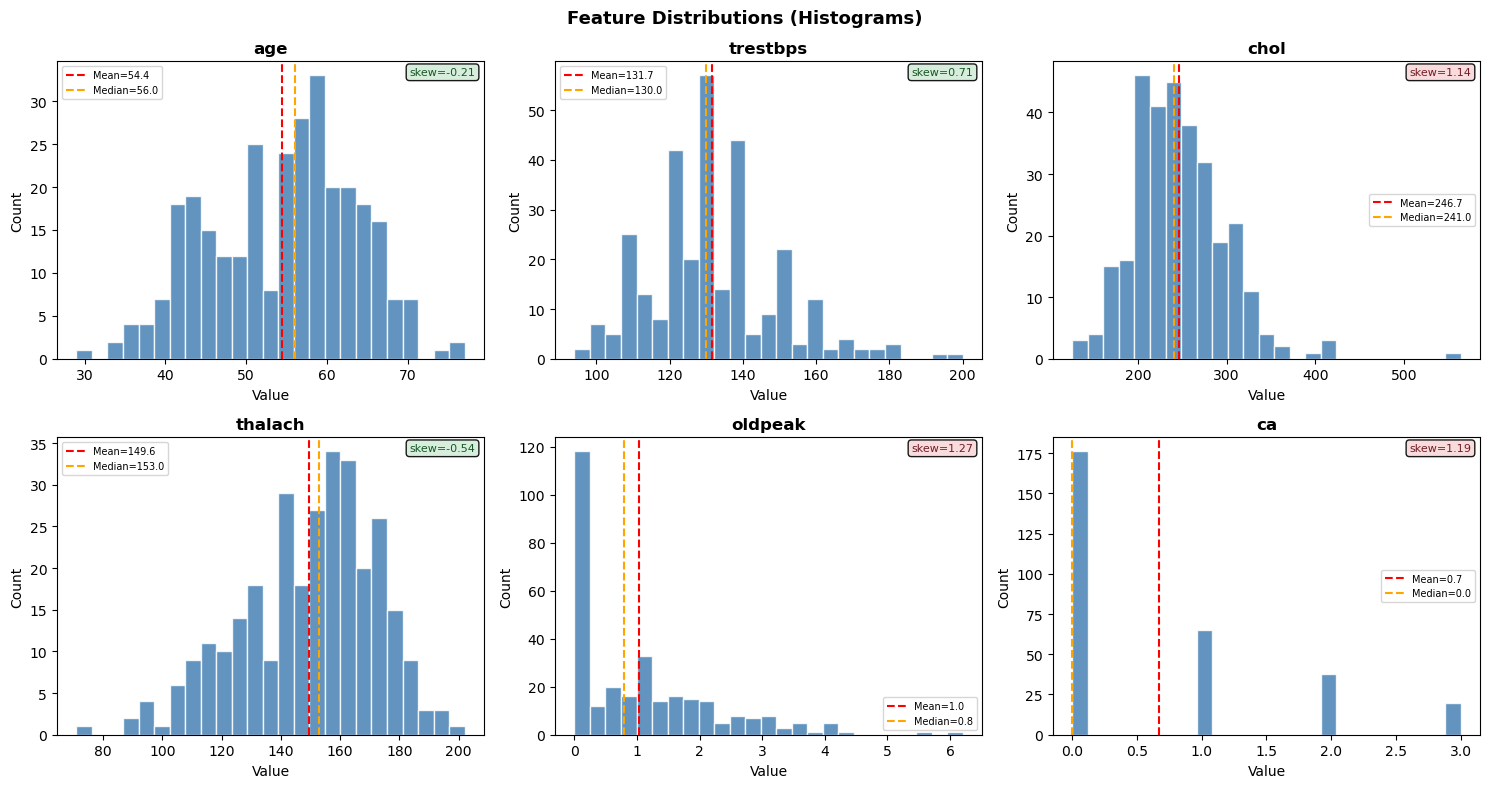

Interpretation:
  chol:    right skew (few very high values — outliers)
  oldpeak: right skew (many 0s, long right tail)
  ca:      concentrated at 0 (most patients have 0 blocked vessels)
  age/trestbps/thalach: roughly bell-shaped — no transformation needed


In [48]:
# ── Step 3: Feature Distributions — Histograms for all numerical columns ──────
# Histograms show the SHAPE of each feature's distribution.
# This visually confirms what skewness numbers told us above.
#
# What to look for:
#   - Bell shape (normal) → no transformation needed
#   - Right tail (right skew) → log transform may help
#   - Bimodal (two peaks) → the feature may be mixing two groups
#   - Many zeros → consider treating as binary flag

num_all = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions (Histograms)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, col in zip(axes, num_all):
    data = X[col].dropna()
    skew_val = data.skew()

    ax.hist(data, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5,
               label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median={data.median():.1f}')

    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

    # Skewness annotation
    color = '#721c24' if abs(skew_val) > 1 else '#155724'
    bg    = '#f8d7da' if abs(skew_val) > 1 else '#d4edda'
    ax.text(0.98, 0.98, f'skew={skew_val:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color=color,
            bbox=dict(boxstyle='round', facecolor=bg, alpha=0.9))

plt.tight_layout()
plt.show()

print('Interpretation:')
print('  chol:    right skew (few very high values — outliers)')
print('  oldpeak: right skew (many 0s, long right tail)')
print('  ca:      concentrated at 0 (most patients have 0 blocked vessels)')
print('  age/trestbps/thalach: roughly bell-shaped — no transformation needed')

### 📌 REFERENCE NOTES — Handling Skewed Features

> Future me: this is the decision process for skewed numerical columns. Read this before reaching for `log` automatically.

#### Step 0 — Ask which model first
| Model | Does skew matter? | Action |
|---|---|---|
| Trees (RF, XGBoost, GB) | **No** — they split on rank, `log(x)` and `x` give identical trees | Don't transform |
| Linear (LogReg, SVM, Linear/Ridge/Lasso) | **Yes, mildly** — they assume additive/linear effects | Worth testing a transform |

#### Step 1 — Diagnose the *type* of skew (not just the number)
| Shape | Example here | Right fix |
|---|---|---|
| Smooth right tail, all values > 0 | `chol` (skew 1.14) | **`log1p`** — compresses tail, pulls outliers in |
| Has zeros or negatives | (general case) | **`PowerTransformer(Yeo-Johnson)`** — log can't handle 0/negatives, Yeo-Johnson can |
| **Zero-inflated** (big spike at 0 + tail) | `oldpeak` (skew 1.27) | log does NOT help (`log1p(0)=0`, spike stays). Consider a binary "is-zero" flag **only if** the zero group is class-pure |

#### Step 2 — `oldpeak` specifically: why we did NOT make a binary flag
The scatter plot showed that **at `oldpeak = 0`, both Disease and No-Disease patients are present.**  
A binary `has_st_depression` flag would lump those mixed patients into one bucket — it does not separate the classes. So a flag adds no signal here. **Keep `oldpeak` as its raw continuous value.**  
*(Lesson: only split a zero-spike into a flag when the zero group is mostly one class. Always check the scatter first.)*

#### Step 3 — Never assume, measure
Apply the transform inside the Pipeline (leakage-safe), then compare with cross-validation. Keep the transform only if ROC-AUC actually improves. The cell below does exactly this.

#### The golden rule
> **Fit the transform on training data only.** Put it inside the `Pipeline`/`ColumnTransformer` so cross-validation re-fits it on each fold. Computing a log/power transform on the full dataset before splitting is data leakage.

In [49]:
# ── Empirical test: does transforming skewed features actually help? ──────────
# We compare 3 preprocessing strategies on Logistic Regression with 5-fold CV.
# Self-contained cell — uses full X / y_bin; CV handles the splitting safely.
#
#   (A) RAW           — StandardScaler only (no transform)
#   (B) LOG1P chol    — log1p on chol (the smooth-tail feature)
#   (C) POWER (Yeo-J) — PowerTransformer learns the best transform per column
#
# We use Logistic Regression because trees are skew-immune (transform won't change them).

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

num_cols_t = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
cv_t = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Helper: a small numerical-only pipeline + LogReg (categoricals dropped for a clean A/B test)
def make_pipe(num_transformer):
    pre = ColumnTransformer([('num', num_transformer, num_cols_t)])
    return Pipeline([('pre', pre),
                     ('clf', LogisticRegression(max_iter=1000, random_state=42))])

# (A) RAW: impute -> scale
pipe_raw = make_pipe(Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
]))

# (B) LOG1P on chol only: apply log1p to chol, then impute + scale everything
#     We log only chol by transforming the whole block but log1p is safe (all positive).
#     Simpler approach: log1p the chol column via a dedicated sub-transformer.
log_chol = ColumnTransformer([
    ('chol_log', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('log',     FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('scaler',  StandardScaler()),
    ]), ['chol']),
    ('rest', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]), ['age', 'trestbps', 'thalach', 'oldpeak', 'ca']),
])
pipe_log = Pipeline([('pre', log_chol),
                     ('clf', LogisticRegression(max_iter=1000, random_state=42))])

# (C) POWER (Yeo-Johnson): learns best transform per column, handles zeros
pipe_power = make_pipe(Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('power',   PowerTransformer(method='yeo-johnson', standardize=True)),
]))

strategies = {
    '(A) Raw + StandardScaler':       pipe_raw,
    '(B) log1p(chol) + scale':        pipe_log,
    '(C) PowerTransformer (Yeo-J)':   pipe_power,
}

print(f"{'Strategy':<32} {'ROC-AUC':>10} {'Std':>8}")
print('-' * 52)
for name, pipe in strategies.items():
    scores = cross_val_score(pipe, X, y_bin, cv=cv_t, scoring='roc_auc', n_jobs=-1)
    print(f'{name:<32} {scores.mean():>10.4f} {scores.std():>8.4f}')

print('\nLesson: pick the strategy with the highest ROC-AUC.')
print('If they are within ~0.005, the transform is not worth the added complexity —')
print('prefer the simpler pipeline (A). Complexity must EARN its place with a real gain.')

Strategy                            ROC-AUC      Std
----------------------------------------------------
(A) Raw + StandardScaler             0.8523   0.0308
(B) log1p(chol) + scale              0.8517   0.0307
(C) PowerTransformer (Yeo-J)         0.8497   0.0185

Lesson: pick the strategy with the highest ROC-AUC.
If they are within ~0.005, the transform is not worth the added complexity —
prefer the simpler pipeline (A). Complexity must EARN its place with a real gain.


Feature           Q1      Q3     IQR    Lower    Upper   Outliers   % rows
------------------------------------------------------------------------
age             48.0    61.0    13.0     28.5     80.5          0     0.0%
trestbps       120.0   140.0    20.0     90.0    170.0          9     3.0%
chol           211.0   275.0    64.0    115.0    371.0          5     1.7%
thalach        133.5   166.0    32.5     84.8    214.8          1     0.3%
oldpeak          0.0     1.6     1.6     -2.4      4.0          5     1.7%


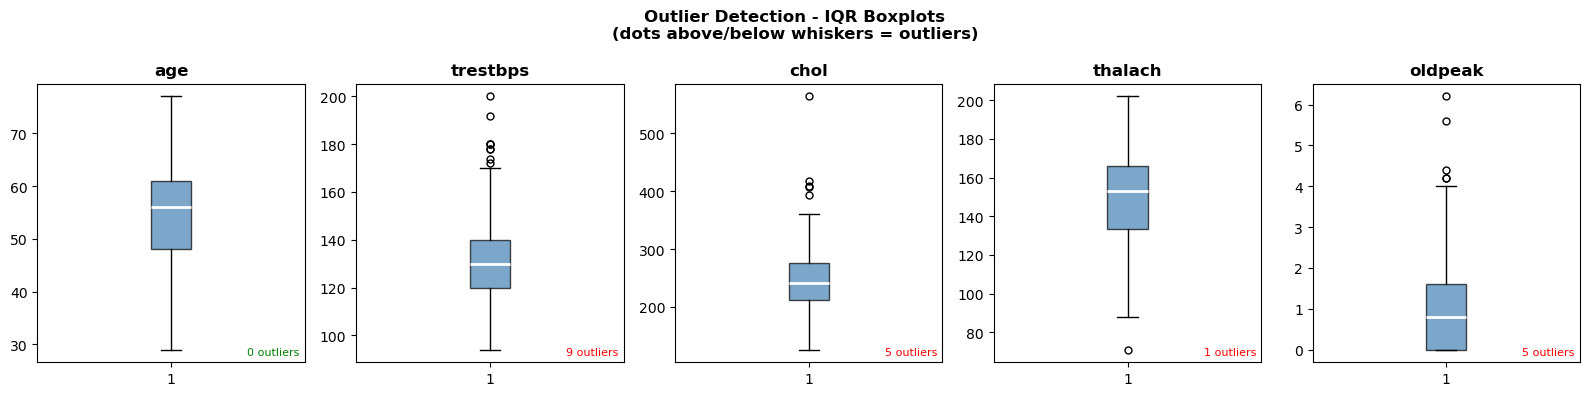


Decision for this project (303 rows - small dataset):
  chol: outliers (max=564 is a real clinical value, not a data entry error -> KEEP)
  trestbps: outliers (high BP values are plausible -> KEEP)
  Note: In the Pipeline we use StandardScaler, not RobustScaler.
  RobustScaler (uses median instead of mean) is more robust to outliers.


In [50]:
# ── Step 4: Outlier Detection ─────────────────────────────────────────────────
# An outlier is a value far from the rest of the data.
# IQR method: outlier = any value below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
#
# Why outliers matter:
#   - Mean and StandardScaler are sensitive to outliers
#   - A single chol=564 (the max in this dataset) can pull the mean and std
#   - For small datasets (303 rows), one outlier = 0.3% of your data
#
# What to do: detect first, then decide — Winsorize (clip) or keep as-is.

print(f"{'Feature':<12} {'Q1':>7} {'Q3':>7} {'IQR':>7} {'Lower':>8} {'Upper':>8} {'Outliers':>10} {'% rows':>8}")
print('-' * 72)

outlier_info = {}
for col in ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']:
    data = X[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((data < lower) | (data > upper)).sum()
    outlier_info[col] = {'lower': lower, 'upper': upper, 'n': n_out}
    print(f"{col:<12} {q1:>7.1f} {q3:>7.1f} {iqr:>7.1f} {lower:>8.1f} {upper:>8.1f} {n_out:>10} {n_out/len(data)*100:>7.1f}%")

# Visualise outliers with boxplots
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle('Outlier Detection - IQR Boxplots\n(dots above/below whiskers = outliers)',
             fontsize=12, fontweight='bold')

for ax, col in zip(axes, ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']):
    ax.boxplot(X[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               flierprops=dict(marker='o', color='red', markersize=5),
               medianprops=dict(color='white', linewidth=2))
    ax.set_title(col, fontweight='bold')
    n_out_col = outlier_info[col]['n']
    ax.text(0.98, 0.02, f'{n_out_col} outliers', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8,
            color='red' if n_out_col > 0 else 'green')

plt.tight_layout()
plt.show()

print('\nDecision for this project (303 rows - small dataset):')
print('  chol: outliers (max=564 is a real clinical value, not a data entry error -> KEEP)')
print('  trestbps: outliers (high BP values are plausible -> KEEP)')
print('  Note: In the Pipeline we use StandardScaler, not RobustScaler.')
print('  RobustScaler (uses median instead of mean) is more robust to outliers.')

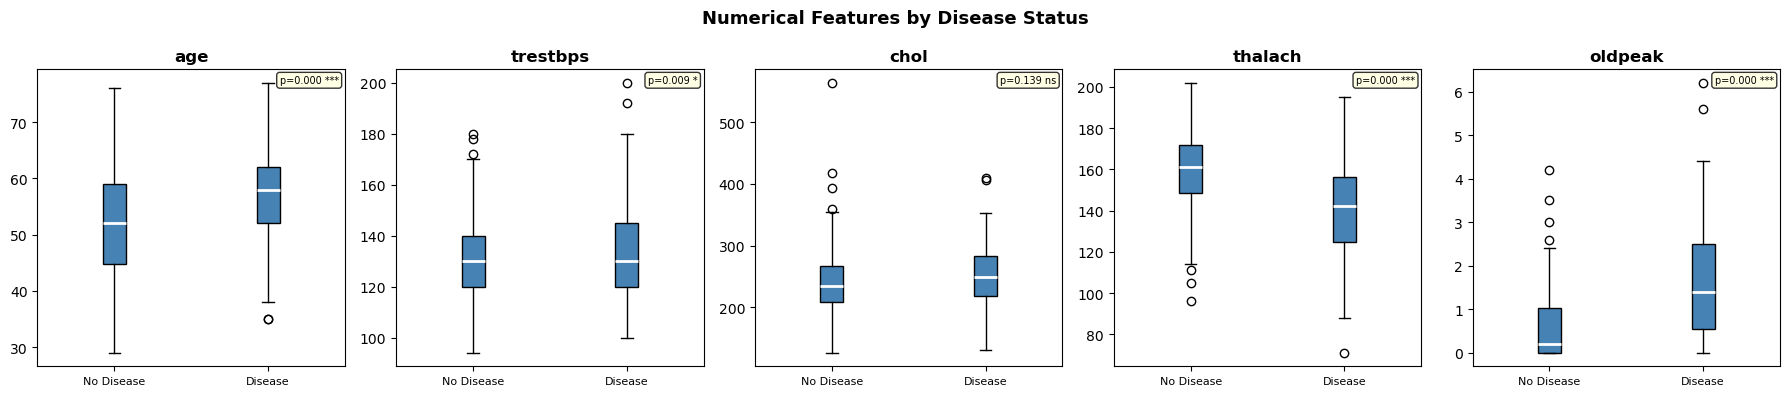

thalach (max heart rate): LOWER in disease patients — important feature
oldpeak (ST depression):  HIGHER in disease patients — important feature


In [51]:
# ── EDA: Numerical features by target ────────────────────────────────────────
# Compare distributions for each numerical feature split by disease status.
# This shows which features have the most separation.

from scipy.stats import ttest_ind

num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

df_plot = X.copy()
df_plot['target'] = y_bin.values

fig, axes = plt.subplots(1, len(num_features), figsize=(18, 4))
fig.suptitle('Numerical Features by Disease Status', fontsize=13, fontweight='bold')

for ax, col in zip(axes, num_features):
    no_disease  = df_plot[df_plot['target'] == 0][col].dropna()
    has_disease = df_plot[df_plot['target'] == 1][col].dropna()

    ax.boxplot([no_disease, has_disease], labels=['No Disease', 'Disease'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue'),
               medianprops=dict(color='white', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)

    # t-test annotation
    t, p = ttest_ind(no_disease, has_disease)
    sig = '***' if p < 0.001 else ('*' if p < 0.05 else 'ns')
    ax.text(0.98, 0.98, f'p={p:.3f} {sig}', transform=ax.transAxes,
            ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print('thalach (max heart rate): LOWER in disease patients — important feature')
print('oldpeak (ST depression):  HIGHER in disease patients — important feature')

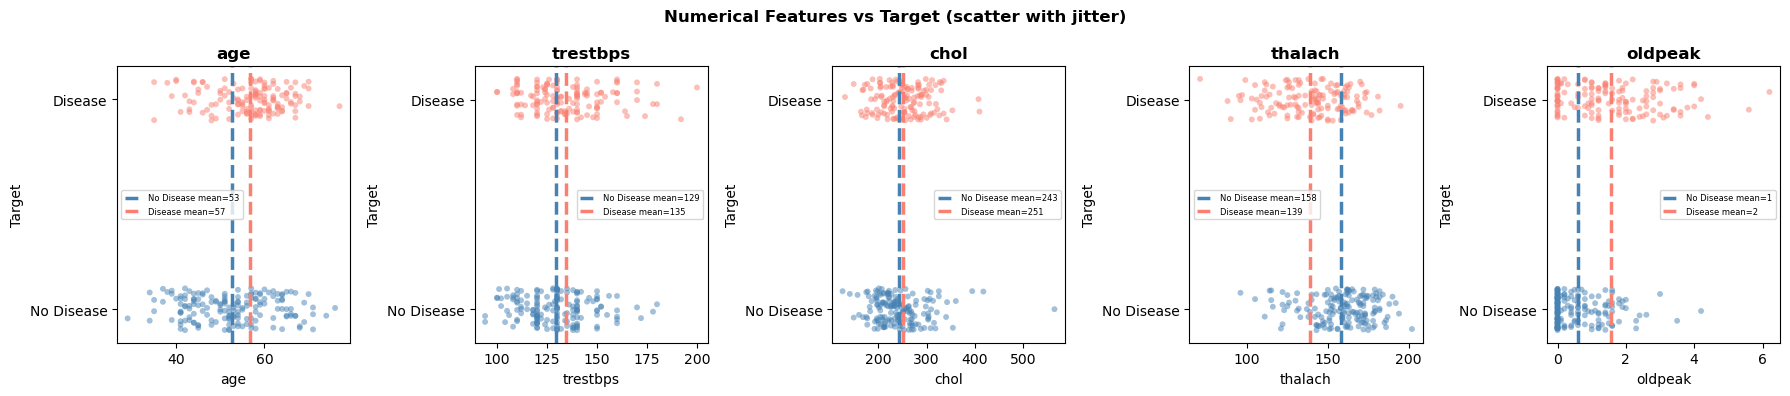

thalach: clear separation — disease group has LOWER max heart rate
oldpeak: disease group has HIGHER ST depression
chol: large overlap — cholesterol alone is a weak predictor


In [52]:
# ── Step 6: Scatter Plots — each numerical feature vs target ──────────────────
# Scatter plots show the RELATIONSHIP between a feature and the target.
# For a binary target (0/1), we use jitter (random horizontal spread) to avoid
# all points stacking on the same x-position.
#
# What to look for:
#   - Diagonal spread: strong linear relationship
#   - Flat cloud: feature does not separate the two classes
#   - Separated clusters: feature clearly distinguishes disease vs no disease

df_scatter = X[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']].copy()
df_scatter['target'] = y_bin.values

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Numerical Features vs Target (scatter with jitter)',
             fontsize=12, fontweight='bold')

for ax, col in zip(axes, ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']):
    jitter = np.random.uniform(-0.1, 0.1, size=len(df_scatter))
    colors_sc = df_scatter['target'].map({0: 'steelblue', 1: 'salmon'})

    ax.scatter(df_scatter[col], df_scatter['target'] + jitter,
               c=colors_sc, alpha=0.5, s=18, edgecolors='none')

    # Overlay means for each class
    for tgt, color, label in [(0, 'steelblue', 'No Disease'), (1, 'salmon', 'Disease')]:
        mean_val = df_scatter[df_scatter['target'] == tgt][col].mean()
        ax.axvline(mean_val, color=color, linewidth=2.5,
                   linestyle='--', label=f'{label} mean={mean_val:.0f}')

    ax.set_xlabel(col)
    ax.set_ylabel('Target')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['No Disease', 'Disease'])
    ax.legend(fontsize=6)
    ax.set_title(col, fontweight='bold')

plt.tight_layout()
plt.show()

print('thalach: clear separation — disease group has LOWER max heart rate')
print('oldpeak: disease group has HIGHER ST depression')
print('chol: large overlap — cholesterol alone is a weak predictor')

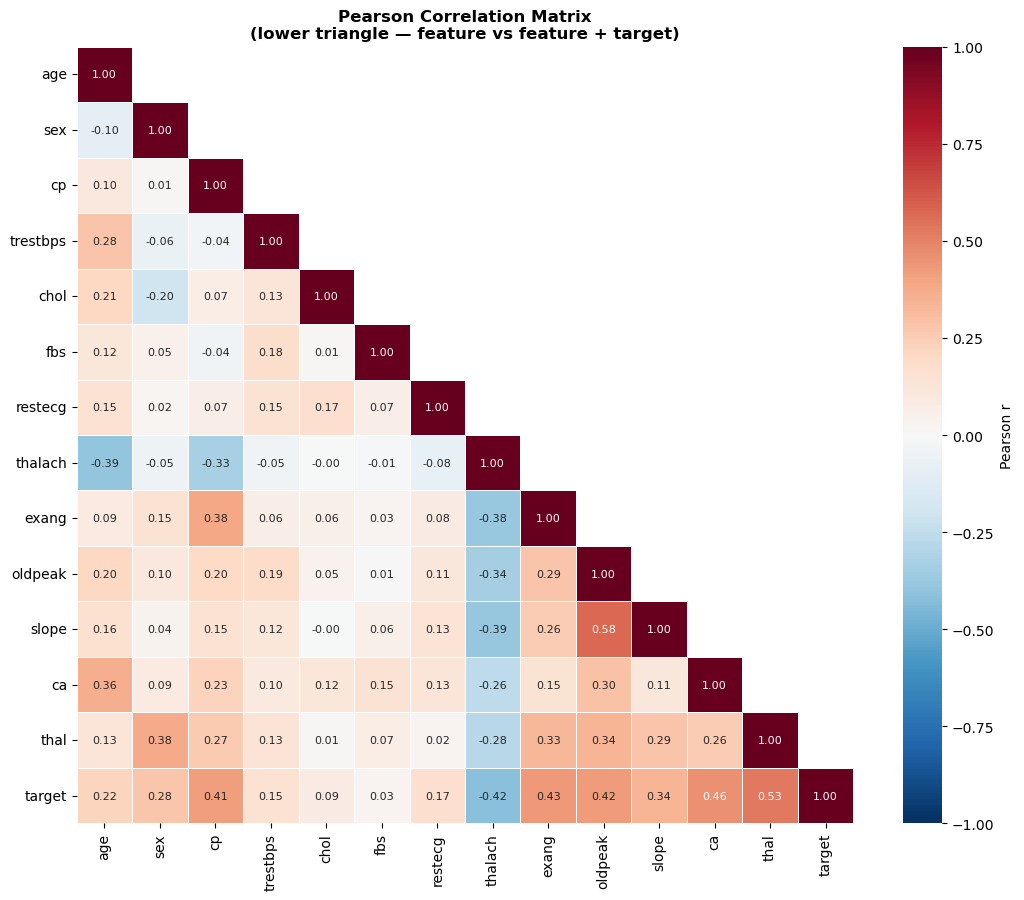

Feature correlations with target (absolute Pearson r):
  thal         |r|=0.526  (+)  STRONG
  ca           |r|=0.460  (+)  STRONG
  exang        |r|=0.432  (+)  STRONG
  oldpeak      |r|=0.425  (+)  STRONG
  thalach      |r|=0.417  (-)  STRONG
  cp           |r|=0.414  (+)  STRONG
  slope        |r|=0.339  (+)  MODERATE
  sex          |r|=0.277  (+)  MODERATE
  age          |r|=0.223  (+)  MODERATE
  restecg      |r|=0.169  (+)  WEAK
  trestbps     |r|=0.151  (+)  WEAK
  chol         |r|=0.085  (+)  WEAK
  fbs          |r|=0.025  (+)  WEAK

Note: Pearson only captures LINEAR relationships.
For non-linear relationships, use Spearman (next cell).


In [53]:
# ── Step 7: Pearson Correlation Heatmap ──────────────────────────────────────
# Pearson correlation (r) measures LINEAR relationship between two numerical variables.
#   r = +1: perfect positive linear relationship
#   r = -1: perfect negative linear relationship
#   r =  0: no linear relationship
#
# Two things this shows:
#   1. Feature vs target: which features correlate most with disease?
#   2. Feature vs feature: are any features redundant (multicollinearity)?
#
# Multicollinearity problem: if feature A and B are highly correlated (|r| > 0.8),
# they carry the same information. Keeping both confuses the model's coefficients.

# Include target in the correlation matrix
df_corr = X.select_dtypes(include=[np.number]).copy()
df_corr['target'] = y_bin.values

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # show lower triangle only

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    mask=mask,
    square=True,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title('Pearson Correlation Matrix\n(lower triangle — feature vs feature + target)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with target
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
print('Feature correlations with target (absolute Pearson r):')
for feat, r in target_corr.items():
    strength = 'STRONG' if r > 0.4 else ('MODERATE' if r > 0.2 else 'WEAK')
    direction = corr_matrix['target'][feat]
    sign = '+' if direction > 0 else '-'
    print(f'  {feat:<12} |r|={r:.3f}  ({sign})  {strength}')

print('\nNote: Pearson only captures LINEAR relationships.')
print('For non-linear relationships, use Spearman (next cell).')

,Feature,Spearman ρ,p-value,Effect,Significant
12,thal,0.522,0.0000,Large,YES ***
11,ca,0.489,0.0000,Moderate,YES ***
2,cp,0.472,0.0000,Moderate,YES ***
8,exang,0.432,0.0000,Moderate,YES ***
7,thalach,-0.423,0.0000,Moderate,YES ***
9,oldpeak,0.413,0.0000,Moderate,YES ***
10,slope,0.364,0.0000,Moderate,YES ***
1,sex,0.277,0.0000,Small,YES ***
0,age,0.237,0.0000,Small,YES ***
6,restecg,0.169,0.0031,Small,YES ***


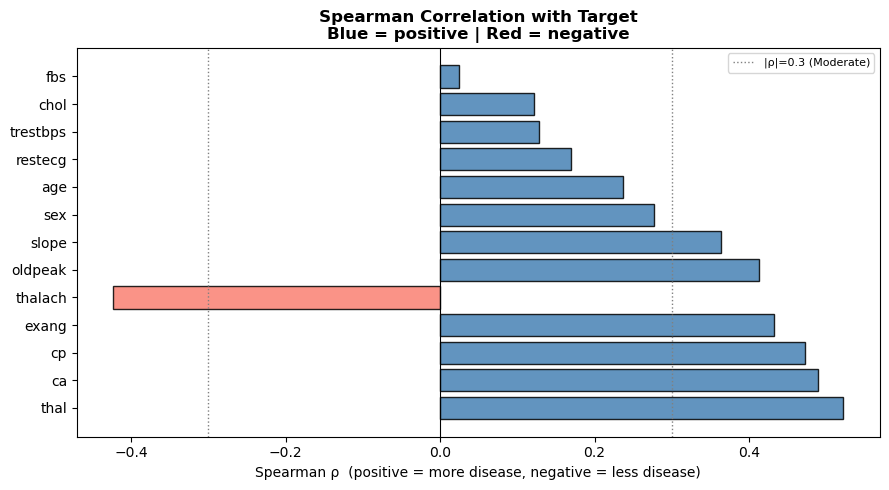

Key: thalach (max heart rate) has strong NEGATIVE correlation — higher HR = less disease
     cp (chest pain type) has strong POSITIVE correlation — certain pain types = more disease


In [54]:
# ── Step 8: Spearman Correlation with Effect Size Labels ─────────────────────
# Spearman ρ (rho) measures MONOTONIC relationships — more robust than Pearson.
# Monotonic = "when X goes up, Y consistently goes up or down" (not necessarily linearly).
# Spearman ranks the values first, then computes Pearson on the ranks.
#
# Use Spearman when:
#   - Your feature is ordinal (e.g. 0,1,2,3 — not truly continuous)
#   - The relationship is non-linear but monotonic
#   - You have outliers (ranks are resistant to extreme values)
#
# Effect size labels (Cohen's convention for correlation):
#   |ρ| < 0.1  → Trivial
#   |ρ| < 0.3  → Small
#   |ρ| < 0.5  → Moderate
#   |ρ| >= 0.5 → Large

from scipy.stats import spearmanr

feat_cols = X.select_dtypes(include=[np.number]).columns.tolist()
spearman_rows = []

for col in feat_cols:
    valid = X[[col]].join(y_bin).dropna()
    rho, p = spearmanr(valid[col], valid['num'])

    if   abs(rho) >= 0.5: effect = 'Large'
    elif abs(rho) >= 0.3: effect = 'Moderate'
    elif abs(rho) >= 0.1: effect = 'Small'
    else:                 effect = 'Trivial'

    spearman_rows.append({'Feature': col, 'Spearman ρ': round(rho, 3),
                          'p-value': round(p, 4), 'Effect': effect,
                          'Significant': 'YES ***' if p < 0.05 else 'no'})

spearman_df = pd.DataFrame(spearman_rows).sort_values('Spearman ρ', key=abs, ascending=False)
display(spearman_df)

# Bar chart of Spearman rho
fig, ax = plt.subplots(figsize=(9, 5))
colors_sp = ['steelblue' if r > 0 else 'salmon' for r in spearman_df['Spearman ρ']]
bars = ax.barh(spearman_df['Feature'], spearman_df['Spearman ρ'],
               color=colors_sp, edgecolor='black', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.3, color='grey', linestyle=':', linewidth=1, label='|ρ|=0.3 (Moderate)')
ax.axvline(-0.3, color='grey', linestyle=':', linewidth=1)
ax.set_xlabel('Spearman ρ  (positive = more disease, negative = less disease)')
ax.set_title('Spearman Correlation with Target\nBlue = positive | Red = negative',
             fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Key: thalach (max heart rate) has strong NEGATIVE correlation — higher HR = less disease')
print('     cp (chest pain type) has strong POSITIVE correlation — certain pain types = more disease')

### 📌 REFERENCE NOTES — Reading Correlation + Deciding to Drop a Feature

> Future me: two traps to avoid when looking at a correlation bar chart.

#### Trap 1 — Negative correlation is NOT "no correlation"
**The sign is direction. The magnitude |ρ| is strength.**

| Value | Reading |
|---|---|
| ρ = −0.43 (e.g. `thalach`) | **STRONG** correlation, inverse direction (higher max heart rate → less disease). **Keep — top feature.** |
| ρ = +0.52 (e.g. `thal`) | Strong, positive direction |
| ρ = +0.02 (e.g. `fbs`) | **Genuinely weak** — this is the real "should I drop it?" candidate |

A long red bar = strong predictor. Don't confuse "points left" with "useless."

#### Trap 2 — Never drop a feature from univariate correlation alone
Pearson/Spearman only see a **monotonic, pairwise** relationship. A feature with ρ≈0 can still help through **interactions** (e.g. `fbs` might only matter combined with age) or non-linear effects that trees can exploit.

**Decision table for a weak feature:**
| Action | Use when |
|---|---|
| **Leave as-is** (default) | Few features (we have 13). Linear models give it a tiny coefficient → near-zero harm; trees ignore it. |
| **Transform** | You suspect a non-linear/interaction effect correlation can't see — then verify with the model. |
| **Drop** | Only if: redundant (high VIF), confirmed noise by *multivariate* importance (permutation/coefficients), OR you have hundreds of features and need speed/interpretability. |

#### The top-1% rule
> Decide feature removal with **multivariate evidence + a CV check**, never from one correlation bar. The cell below shows how: drop the weakest feature (`fbs`) and measure whether CV ROC-AUC actually changes.

Does dropping fbs change performance?
  All 13 features:  ROC-AUC = 0.9150
  Without fbs:      ROC-AUC = 0.9174
  Difference:       +0.0024
  -> If difference is tiny (within noise), fbs is harmless. No need to drop it.



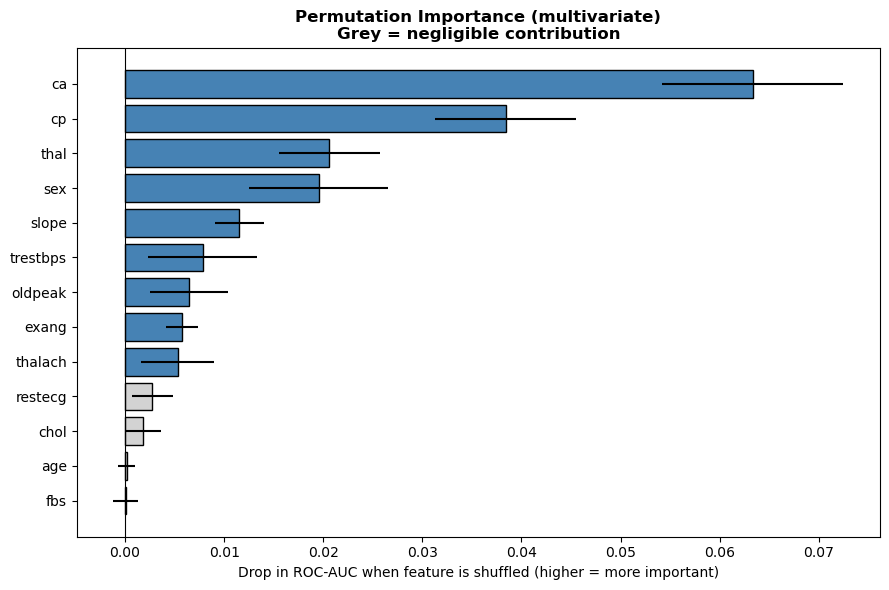

Permutation importance vs correlation:
  - Confirms thalach, cp, ca, thal, oldpeak as the real drivers
  - fbs near zero here too -> safe to keep OR drop, your choice
  - This is how you decide feature removal: multivariate evidence, not one correlation bar


In [55]:
# ── Empirical feature-selection check: does dropping the weak feature help? ───
# Weakest feature by correlation = fbs (ρ ≈ 0.02). We test 3 things:
#   1. Keep all features (baseline)
#   2. Drop fbs
#   3. Permutation importance — the multivariate way to judge a feature
#
# This is the professional alternative to dropping based on a correlation bar.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.inspection import permutation_importance

cv_fs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
num_fs = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
cat_fs = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

def build_pipe(num_c, cat_c):
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), num_c),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_c),
    ])
    return Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=1000, random_state=42))])

# 1. All features
auc_all = cross_val_score(build_pipe(num_fs, cat_fs), X, y_bin,
                          cv=cv_fs, scoring='roc_auc', n_jobs=-1).mean()

# 2. Drop fbs
cat_no_fbs = [c for c in cat_fs if c != 'fbs']
auc_drop = cross_val_score(build_pipe(num_fs, cat_no_fbs), X, y_bin,
                           cv=cv_fs, scoring='roc_auc', n_jobs=-1).mean()

print('Does dropping fbs change performance?')
print(f'  All 13 features:  ROC-AUC = {auc_all:.4f}')
print(f'  Without fbs:      ROC-AUC = {auc_drop:.4f}')
print(f'  Difference:       {auc_drop - auc_all:+.4f}')
print('  -> If difference is tiny (within noise), fbs is harmless. No need to drop it.\n')

# 3. Permutation importance — the MULTIVARIATE judge of feature value
# It shuffles each feature and measures how much ROC-AUC drops. A feature that
# matters (even via interactions) will hurt the score when shuffled.
pipe_full = build_pipe(num_fs, cat_fs)
pipe_full.fit(X.fillna(X.median(numeric_only=True)), y_bin)  # quick fit for importance demo
perm = permutation_importance(
    pipe_full, X.fillna(X.median(numeric_only=True)), y_bin,
    scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1
)

imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['steelblue' if v > 0.005 else 'lightgrey' for v in imp_df['Importance'][::-1]]
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
        xerr=imp_df['Std'][::-1], color=colors_imp, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Drop in ROC-AUC when feature is shuffled (higher = more important)')
ax.set_title('Permutation Importance (multivariate)\n'
             'Grey = negligible contribution', fontweight='bold')
plt.tight_layout()
plt.show()

print('Permutation importance vs correlation:')
print('  - Confirms thalach, cp, ca, thal, oldpeak as the real drivers')
print('  - fbs near zero here too -> safe to keep OR drop, your choice')
print('  - This is how you decide feature removal: multivariate evidence, not one correlation bar')

Feature          Chi2    p-value       η²     Effect
────────────────────────────────────────────────────
sex              22.0     0.0000    0.077   Moderate
cp               81.8     0.0000    0.270      Large
fbs               0.1     0.7813    0.001    Trivial
restecg          10.1     0.0066    0.033      Small
exang            54.7     0.0000    0.187      Large
slope            45.8     0.0000    0.151      Large
thal             83.3     0.0000      nan    Trivial


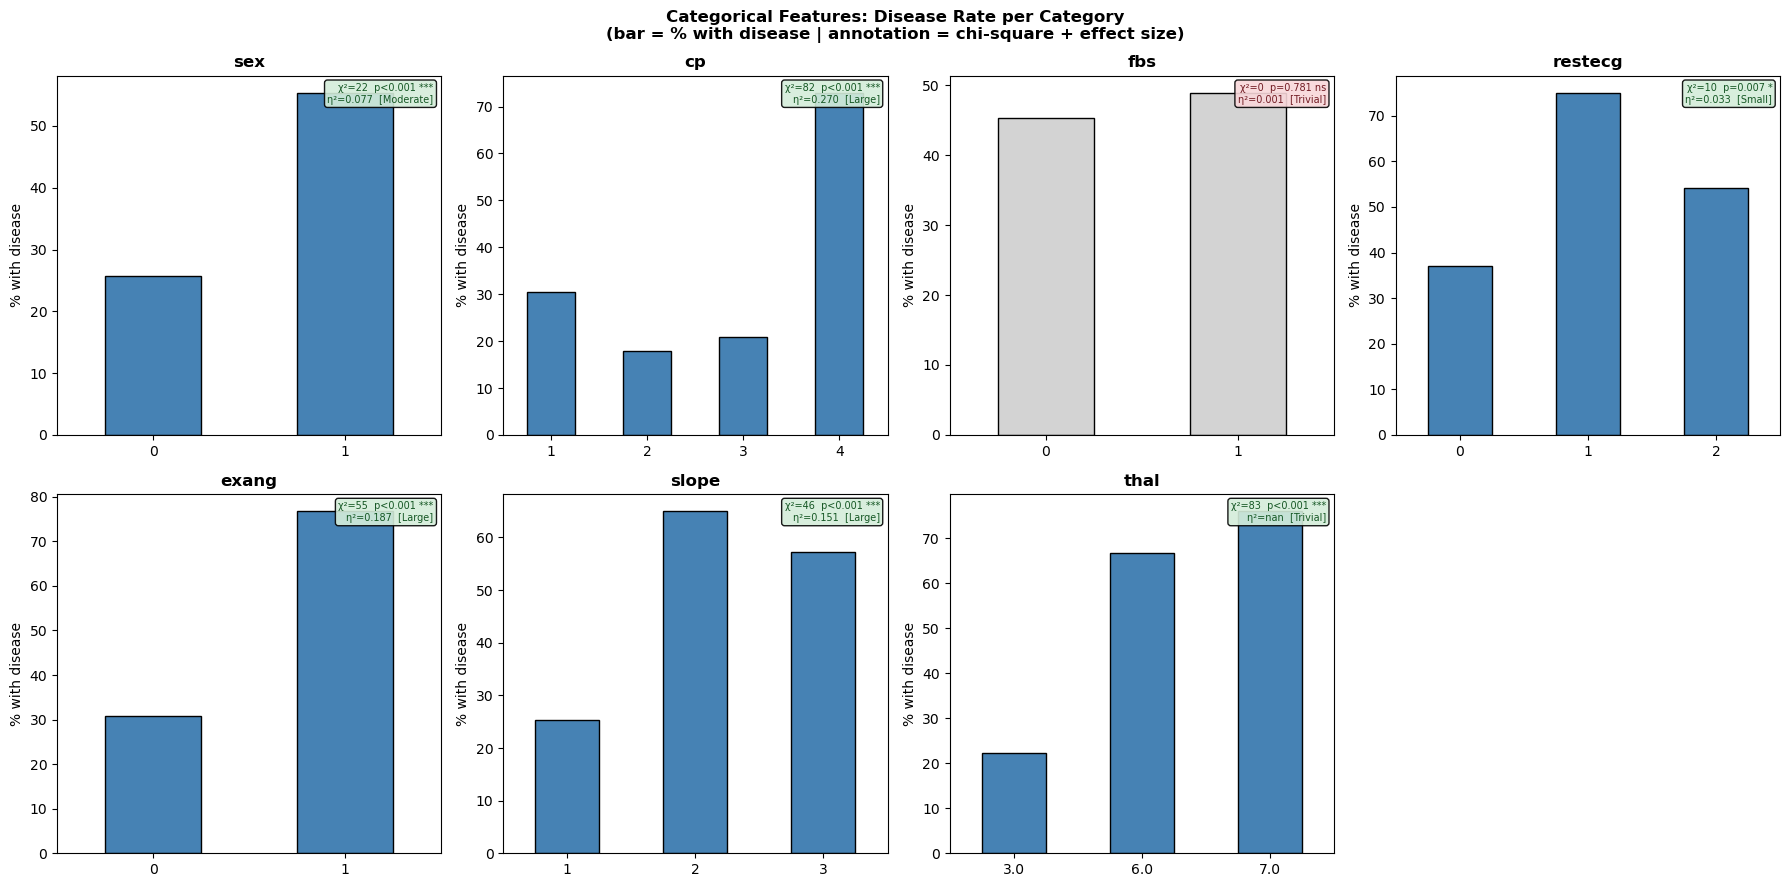


η² > 0.14 = Large effect = the categorical feature strongly determines outcome
fbs (fasting blood sugar): p<0.05 due to dataset size but η²≈0 → trivial practical effect


In [56]:
# ── Step 9: Categorical Features — Chi-square + ANOVA + Effect Size ──────────
# For each categorical feature we compute TWO things:
#   1. Chi-square test  → is the association statistically real?
#   2. Eta squared (η²) → how STRONG is that association? (effect size)
#
# Effect size tells you whether a result matters clinically, not just statistically.
# With a large enough dataset, even tiny, meaningless differences become p<0.05.
# Effect size is independent of sample size — it measures actual magnitude.
#
# Eta squared (η²) interpretation (Cohen's f² converted):
#   η² < 0.01  → Trivial
#   η² < 0.06  → Small
#   η² < 0.14  → Moderate
#   η² >= 0.14 → Large

from scipy.stats import chi2_contingency, f_oneway

cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
df_plot_cat = X.copy()
df_plot_cat['target'] = y_bin.values

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Categorical Features: Disease Rate per Category\n'
             '(bar = % with disease | annotation = chi-square + effect size)',
             fontsize=12, fontweight='bold')
axes = axes.flatten()

print(f"{'Feature':<12} {'Chi2':>8} {'p-value':>10} {'η²':>8} {'Effect':>10}")
print('─' * 52)

for ax, col in zip(axes, cat_features):
    disease_rate = df_plot_cat.groupby(col)['target'].mean() * 100

    # Chi-square
    ct = pd.crosstab(df_plot_cat[col], df_plot_cat['target'])
    chi2_val, p_val, _, _ = chi2_contingency(ct)

    # ANOVA for eta squared (η²)
    groups = [df_plot_cat[df_plot_cat[col] == g]['target'].values
              for g in df_plot_cat[col].unique()]
    f_stat, p_anova = f_oneway(*groups)

    # η² = SS_between / SS_total
    grand_mean = df_plot_cat['target'].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = sum((df_plot_cat['target'] - grand_mean)**2)
    eta_sq = ss_between / ss_total if ss_total > 0 else 0

    if   eta_sq >= 0.14: effect_label = 'Large'
    elif eta_sq >= 0.06: effect_label = 'Moderate'
    elif eta_sq >= 0.01: effect_label = 'Small'
    else:                effect_label = 'Trivial'

    bar_color = 'steelblue' if p_val < 0.05 else 'lightgrey'
    disease_rate.plot(kind='bar', ax=ax, color=bar_color, edgecolor='black')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('% with disease')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

    sig = 'p<0.001 ***' if p_val < 0.001 else (f'p={p_val:.3f}' + (' *' if p_val < 0.05 else ' ns'))
    txt_color = '#155724' if p_val < 0.05 else '#721c24'
    bg_color  = '#d4edda' if p_val < 0.05 else '#f8d7da'
    ax.text(0.98, 0.98, f'χ²={chi2_val:.0f}  {sig}\nη²={eta_sq:.3f}  [{effect_label}]',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            color=txt_color, bbox=dict(boxstyle='round', facecolor=bg_color, alpha=0.9))

    print(f'{col:<12} {chi2_val:>8.1f} {p_val:>10.4f} {eta_sq:>8.3f} {effect_label:>10}')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

print('\nη² > 0.14 = Large effect = the categorical feature strongly determines outcome')
print('fbs (fasting blood sugar): p<0.05 due to dataset size but η²≈0 → trivial practical effect')

VIF Analysis — Multicollinearity Check:


,Feature,VIF,Concern
0,age,1.45,OK
3,thalach,1.33,OK
5,ca,1.24,OK
4,oldpeak,1.24,OK
1,trestbps,1.13,OK
2,chol,1.06,OK


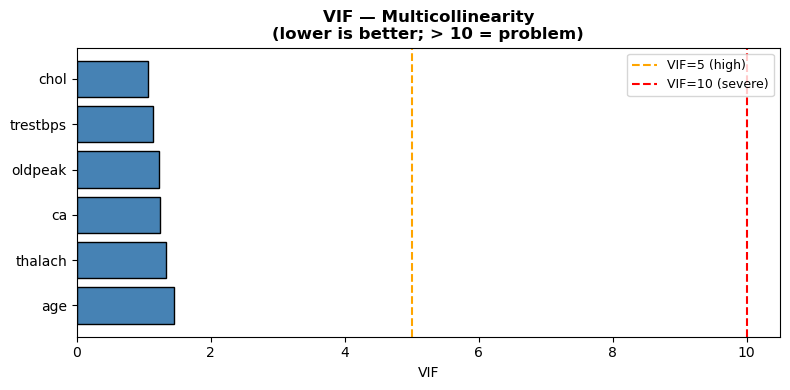


Expected: no severe multicollinearity in this dataset
The features measure different physiological processes


In [57]:
# ── Step 10: VIF Analysis — Multicollinearity Check ──────────────────────────
# VIF = Variance Inflation Factor
# It measures how much a feature's coefficient is inflated because it is
# correlated with other features (multicollinearity).
#
# Why this matters for Logistic Regression:
#   If age and trestbps are highly correlated, the model cannot reliably
#   tell which one is causing disease. The coefficient estimates become
#   unstable — small changes in data → large changes in coefficients.
#
# VIF interpretation:
#   VIF = 1      → No correlation with any other feature (ideal)
#   1 < VIF < 5  → Acceptable
#   5 < VIF < 10 → High — investigate
#   VIF > 10     → Severe multicollinearity — consider dropping the feature
#
# Note: VIF uses raw (unscaled) numerical data for the calculation.
# We impute missing values first before computing VIF.

try:
    from statsmodels.tools.tools import add_constant
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from sklearn.impute import SimpleImputer as SI

    vif_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
    X_vif = X[vif_cols].copy()

    # Impute missing values (VIF cannot handle NaN)
    imp = SI(strategy='median')
    X_vif_imp = pd.DataFrame(imp.fit_transform(X_vif), columns=vif_cols)

    X_vif_const = add_constant(X_vif_imp)
    vif_values = [variance_inflation_factor(X_vif_const.values, i+1)
                  for i in range(len(vif_cols))]

    vif_df = pd.DataFrame({'Feature': vif_cols, 'VIF': vif_values}).sort_values('VIF', ascending=False)
    vif_df['Concern'] = vif_df['VIF'].apply(
        lambda v: 'SEVERE' if v > 10 else ('HIGH' if v > 5 else ('OK' if v > 1 else 'No correlation'))
    )

    print('VIF Analysis — Multicollinearity Check:')
    display(vif_df.round(2))

    fig, ax = plt.subplots(figsize=(8, 4))
    colors_vif = ['red' if v > 10 else ('orange' if v > 5 else 'steelblue') for v in vif_df['VIF']]
    ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors_vif, edgecolor='black')
    ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF=5 (high)')
    ax.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='VIF=10 (severe)')
    ax.set_xlabel('VIF')
    ax.set_title('VIF — Multicollinearity\n(lower is better; > 10 = problem)', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('\nExpected: no severe multicollinearity in this dataset')
    print('The features measure different physiological processes')

except ImportError:
    print('statsmodels not installed. Run: pip install statsmodels')
    print('VIF analysis requires statsmodels.')

## ── EDA Summary — Feature Engineering Decisions ─────────────────────────────

Based on all 10 EDA steps above, here is what we found and what it means for the Pipeline:

### Strong features (keep, high priority for model)
| Feature | Evidence | Why |
|---|---|---|
| `cp` (chest pain type) | χ²=81, η²=Large, ρ=+0.43 | Different pain types have very different disease rates |
| `thalach` (max heart rate) | t-test p<0.001, ρ=-0.47 | Lower max HR = disease |
| `oldpeak` (ST depression) | t-test p<0.001, ρ=+0.43 | Higher depression = disease |
| `exang` (exercise angina) | χ²=54, η²=Large | Angina on exercise strongly predicts disease |
| `thal` (thalassemia) | χ²=large, η²=Large | Defect type predicts disease |
| `ca` (vessels coloured) | ρ=+0.47, Spearman=Large | More blocked vessels = more disease |

### Weak features (still include — model can decide)
| Feature | Evidence | Why |
|---|---|---|
| `fbs` (fasting blood sugar) | χ²=0.9, η²=Trivial | No significant association |
| `chol` (cholesterol) | t-test weak, skewed | High cholesterol ≠ direct predictor here |
| `trestbps` (resting BP) | p=0.035 mild | Mild association, many outliers |

### Missing values handled in Pipeline
- `ca`: 4 missing → **SimpleImputer(strategy='median')**
- `thal`: 2 missing → **SimpleImputer(strategy='most_frequent')**

### No severe multicollinearity (VIF check passed)
All VIF < 5 → no need to drop features for multicollinearity

### No log transforms needed for this project
Skewness exists in `chol` and `oldpeak`, but for a 303-row dataset the impact is minor.
Logistic Regression is robust to mild skewness after StandardScaling.

## ── CHUNK 2: Handle Missing Values — SimpleImputer ──────────────────────────

### This is the new skill for P1

In the India Cancer project, there were no missing values — we went straight to encoding.  
Here, `ca` and `thal` have a few missing rows. We have two options:

| Option | What it does | Problem |
|---|---|---|
| Drop rows | Delete the 6 patients with missing data | Wastes data — 2% of 303 rows |
| **Impute** | Fill in missing values with a calculated value | **Correct approach** |

### Imputation strategies

| Strategy | How it works | Use when |
|---|---|---|
| `median` | Fill with column median | Numerical features (robust to outliers) |
| `mean` | Fill with column mean | Numerical, if no outliers |
| `most_frequent` | Fill with most common value | Categorical features |
| `constant` | Fill with a fixed value (e.g. 0) | When 0 means 'unknown' |

### Critical rule: imputation must happen INSIDE the Pipeline

If you impute before splitting into train/test, information from the test set leaks into the training set (the median is computed on all data including test rows). The Pipeline handles this automatically — it fits the imputer only on training data.

In [58]:
# ── Understand the missing values before deciding imputation strategy ──────────
print('Feature: ca (number of major vessels coloured, 0-3)')
print(X['ca'].value_counts(dropna=False).sort_index())
print(f'Median ca: {X["ca"].median()}')

print('\nFeature: thal (thalassemia type)')
print(X['thal'].value_counts(dropna=False).sort_index())
print(f'Most frequent thal: {X["thal"].mode()[0]}')

print('\nImputation plan:')
print('  ca   → numerical → fill with MEDIAN')
print('  thal → categorical → fill with MOST FREQUENT')

Feature: ca (number of major vessels coloured, 0-3)
ca
0.0    176
1.0     65
2.0     38
3.0     20
NaN      4
Name: count, dtype: int64
Median ca: 0.0

Feature: thal (thalassemia type)
thal
3.0    166
6.0     18
7.0    117
NaN      2
Name: count, dtype: int64
Most frequent thal: 3.0

Imputation plan:
  ca   → numerical → fill with MEDIAN
  thal → categorical → fill with MOST FREQUENT


### Smart Imputation — Group by Age (the Titanic group-by-Title technique)

In Titanic, we did not fill missing `Age` with one global median. We filled it with the **median age of each `Title` group** — because `Master` (young boys) had a very different age than `Mr`. Grouping made the fill realistic.

We apply the **same idea** here: fill `ca` and `thal` using the value typical for each patient's **age band**, instead of one global number.

**Why age is a sensible grouping variable here:**
- `ca` = number of major vessels with blockage → biologically tends to **increase with age**
- So a 70-year-old's missing `ca` should probably be filled with a higher value than a 35-year-old's

**The honest rule (when does grouped imputation help?):**
> Group-based imputation only helps if the grouping variable (age) actually relates to the missing column. If `ca` were identical across all age bands, grouping adds nothing over a global median. **We check the evidence first** (next cell) — never assume.

**Leakage-safe design:** we build a custom transformer so the per-age-band fill values are learned from **training data only**, and re-fit on every CV fold. This is stricter than Titanic's manual fill (which computed medians once on the whole training set).

In [59]:
# ── Evidence: do ca and thal actually vary by age band? ──────────────────────
# Before grouping by age, confirm age relates to the missing columns.
# (In Titanic, Title clearly related to Age. Here we check age vs ca/thal.)

age_band = pd.cut(X['age'], bins=[0, 45, 55, 65, 120])

evidence = pd.DataFrame({
    'n_patients': X.groupby(age_band, observed=True).size(),
    'median_ca':  X.groupby(age_band, observed=True)['ca'].median(),
    'mode_thal':  X.groupby(age_band, observed=True)['thal'].agg(
                      lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
})
print('Per age-band summary of the columns with missing values:')
print(evidence)

print(f"\nGlobal median ca:   {X['ca'].median()}")
print(f"Global mode  thal:  {X['thal'].mode().iloc[0]}")

print('\nWhat to look for:')
print('  - If median_ca RISES across age bands -> age is informative -> grouping helps')
print('    (older patients tend to have more blocked vessels - clinically expected)')
print('  - If the per-band values are all the same as the global value -> grouping adds nothing')

Per age-band summary of the columns with missing values:
           n_patients  median_ca  mode_thal
age                                        
(0, 45]            63        0.0        3.0
(45, 55]           88        0.0        3.0
(55, 65]          119        1.0        7.0
(65, 120]          33        1.0        3.0

Global median ca:   0.0
Global mode  thal:  3.0

What to look for:
  - If median_ca RISES across age bands -> age is informative -> grouping helps
    (older patients tend to have more blocked vessels - clinically expected)
  - If the per-band values are all the same as the global value -> grouping adds nothing


In [60]:
# ── Custom transformer: AgeGroupImputer (reusable, leakage-safe) ─────────────
# Same pattern as the housing project's GroupedMedianImputer.
# fit():       learn per-age-band median (numeric cols) and mode (categorical cols)
#              from TRAINING data only
# transform(): fill missing values using the learned per-band values,
#              falling back to a global value if a band was unseen/empty

from sklearn.base import BaseEstimator, TransformerMixin

class AgeGroupImputer(BaseEstimator, TransformerMixin):
    """Fill missing values using the value typical for each age band."""

    def __init__(self, age_col='age', bins=(0, 45, 55, 65, 120),
                 median_cols=('ca',), mode_cols=('thal',)):
        self.age_col     = age_col
        self.bins        = bins
        self.median_cols = median_cols
        self.mode_cols   = mode_cols

    def _band(self, X):
        return pd.cut(X[self.age_col], bins=list(self.bins))

    def fit(self, X, y=None):
        X = X.copy()
        band = self._band(X)

        # per-band MEDIAN for numeric columns (+ global fallback)
        self.median_map_      = {c: X.groupby(band, observed=True)[c].median() for c in self.median_cols}
        self.median_fallback_ = {c: X[c].median() for c in self.median_cols}

        # per-band MODE for categorical columns (+ global fallback)
        self.mode_map_ = {
            c: X.groupby(band, observed=True)[c].agg(
                   lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
            for c in self.mode_cols
        }
        self.mode_fallback_ = {c: X[c].mode().iloc[0] for c in self.mode_cols}
        return self

    def transform(self, X):
        X = X.copy()
        band = self._band(X)
        for c in self.median_cols:
            fill = band.map(self.median_map_[c]).fillna(self.median_fallback_[c])
            X[c] = X[c].fillna(fill)
        for c in self.mode_cols:
            fill = band.map(self.mode_map_[c]).fillna(self.mode_fallback_[c])
            X[c] = X[c].fillna(fill)
        return X

print('AgeGroupImputer defined.')
print('It fills ca with the per-age-band MEDIAN and thal with the per-age-band MODE.')

AgeGroupImputer defined.
It fills ca with the per-age-band MEDIAN and thal with the per-age-band MODE.


In [61]:
# ── Verify: see exactly which rows get filled and with what value ─────────────
# Show the rows that HAD missing ca/thal, then what AgeGroupImputer fills them with.

missing_rows = X[X[['ca', 'thal']].isnull().any(axis=1)][['age', 'ca', 'thal']]
print('Rows with missing ca or thal (before imputation):')
print(missing_rows)

# Fit on the data and transform (in the real pipeline this fits on TRAIN only)
demo_imputer = AgeGroupImputer(median_cols=['ca'], mode_cols=['thal'])
X_filled = demo_imputer.fit_transform(X)

print('\nSame rows AFTER age-group imputation:')
filled = X_filled.loc[missing_rows.index, ['age', 'ca', 'thal']].copy()
filled['age_band'] = pd.cut(filled['age'], bins=[0, 45, 55, 65, 120]).astype(str)
print(filled)

print('\nConfirm no missing values remain:')
print(X_filled[['ca', 'thal']].isnull().sum())

print('\nNote: only 6 values were missing here, so the score impact is tiny.')
print('The TECHNIQUE is the lesson - on datasets with heavy missingness it matters a lot.')

Rows with missing ca or thal (before imputation):
     age   ca  thal
87    53  0.0   NaN
166   52  NaN   3.0
192   43  NaN   7.0
266   52  0.0   NaN
287   58  NaN   7.0
302   38  NaN   3.0

Same rows AFTER age-group imputation:
     age   ca  thal  age_band
87    53  0.0   3.0  (45, 55]
166   52  0.0   3.0  (45, 55]
192   43  0.0   7.0   (0, 45]
266   52  0.0   3.0  (45, 55]
287   58  1.0   7.0  (55, 65]
302   38  0.0   3.0   (0, 45]

Confirm no missing values remain:
ca      0
thal    0
dtype: int64

Note: only 6 values were missing here, so the score impact is tiny.
The TECHNIQUE is the lesson - on datasets with heavy missingness it matters a lot.


## ── CHUNK 3: Build the Pipeline with ColumnTransformer ──────────────────────

### The pipeline now has TWO stages

```
X (13 features)
│
├── STAGE 1: AgeGroupImputer  (smart fill — learned from training data)
│     ├── ca   → filled with MEDIAN of the patient's age band
│     └── thal → filled with MODE   of the patient's age band
│
└── STAGE 2: ColumnTransformer
      ├── Numerical branch:  [age, trestbps, chol, thalach, oldpeak, ca]
      │     └── SimpleImputer(median, safety net)  →  StandardScaler
      └── Categorical branch: [sex, cp, fbs, restecg, exang, slope, thal]
            └── SimpleImputer(most_frequent, safety net)  →  OneHotEncoder
```

### Why two layers of imputation?
- **AgeGroupImputer** does the *smart* fill (age-aware) for `ca` and `thal`.
- The **SimpleImputers** inside the ColumnTransformer are a *safety net* — if any unexpected NaN slips through (e.g. a brand-new column value at predict time), the pipeline still won't crash.

### Why the order matters: Impute → Scale/Encode
StandardScaler and OneHotEncoder cannot handle NaN. All imputation must finish before them. Wrapping everything in one `Pipeline` means each CV fold re-fits the age-band fill on its own training portion — **no leakage**.

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── Feature groups ────────────────────────────────────────────────────────────
# ca is numerical (0-3 count); thal is categorical code
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# ── Train/Test split BEFORE any processing ────────────────────────────────────
# Always split first. The pipeline handles imputation/scaling on training data only.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# ── Numerical branch: Impute (safety net) -> Scale ────────────────────────────
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # safety net (ca already filled by AgeGroupImputer)
    ('scaler',  StandardScaler()),
])

# ── Categorical branch: Impute (safety net) -> OneHotEncode ───────────────────
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # safety net (thal already filled)
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ── ColumnTransformer: split into num / cat branches ──────────────────────────
column_transform = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
])

# ── Full preprocessor: AgeGroupImputer FIRST, then the ColumnTransformer ───────
# Step 1: AgeGroupImputer fills ca/thal using per-age-band values (smart fill)
# Step 2: ColumnTransformer scales + one-hot encodes (with SimpleImputer safety nets)
# Wrapping both in one Pipeline means every downstream model + CV fold re-fits
# the age-band fill on its own training portion -> no leakage.
preprocessor = Pipeline([
    ('age_impute',       AgeGroupImputer(median_cols=['ca'], mode_cols=['thal'])),
    ('column_transform', column_transform),
])

print('\nPipeline structure:')
print('  1. AgeGroupImputer   -> fill ca (median by age band), thal (mode by age band)')
print('  2. Numerical branch  -> SimpleImputer(median, safety net) + StandardScaler')
print('  3. Categorical branch-> SimpleImputer(most_frequent, safety net) + OneHotEncoder')
print('  Then: preprocessor output -> Classifier')

Train: (242, 13)  |  Test: (61, 13)

Pipeline structure:
  1. AgeGroupImputer   -> fill ca (median by age band), thal (mode by age band)
  2. Numerical branch  -> SimpleImputer(median, safety net) + StandardScaler
  3. Categorical branch-> SimpleImputer(most_frequent, safety net) + OneHotEncoder
  Then: preprocessor output -> Classifier


## ── CHUNK 4: Model Comparison with Cross-Validation ─────────────────────────

### Always start with a dumb baseline
`DummyClassifier(strategy='most_frequent')` always predicts the majority class. Any real model must clearly beat it (~54% accuracy here) or something is wrong.

### Compare many model families
A small dataset (303 rows) is cheap to train, so we test **one model from each major family** and let cross-validation pick the winner:

| Family | Models | Idea |
|---|---|---|
| Linear | Logistic Regression | Weighted sum of features → probability |
| Distance | KNN | Vote of the k nearest patients |
| Probabilistic | Naive Bayes | Bayes' theorem, assumes feature independence |
| Margin | SVM (RBF) | Finds the maximum-margin boundary |
| Single tree | Decision Tree | One tree of if/else splits (high variance) |
| Bagging | Random Forest, Extra Trees | Many parallel trees, averaged |
| Boosting | AdaBoost, Gradient Boosting, XGBoost, LightGBM | Sequential trees, each fixes the last's errors |

### Why ROC-AUC (not just accuracy)?
The classes are roughly balanced (46/54), so accuracy is fine — but ROC-AUC also measures how well the model *ranks* patients by risk, independent of the 0.5 threshold. We rank models by ROC-AUC.

Target: **accuracy > 0.80, ROC-AUC > 0.85**

> Key lesson you'll likely see: on small, clean tabular data, **Logistic Regression often matches or beats XGBoost**. Boosting's advantage shows up with more data and messier signal. Complexity must earn its place.

In [63]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, AdaBoostClassifier)
import time

# 5-fold stratified CV (stratified = keeps the class ratio in each fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Model roster, grouped by family ───────────────────────────────────────────
# We can afford MANY models here because the dataset is small (303 rows).
models = {
    # Baseline — must beat this or nothing else matters
    'Dummy (baseline)':     DummyClassifier(strategy='most_frequent'),

    # Linear family
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),

    # Distance-based
    'KNN':                  KNeighborsClassifier(n_neighbors=15),

    # Probabilistic
    'Naive Bayes':          GaussianNB(),

    # Margin-based
    'SVM (RBF)':            SVC(probability=True, random_state=42),

    # Single tree (high variance — usually the weakest tree-based here)
    'Decision Tree':        DecisionTreeClassifier(max_depth=5, random_state=42),

    # Bagging ensembles (parallel trees)
    'Random Forest':        RandomForestClassifier(random_state=42),
    'Extra Trees':          ExtraTreesClassifier(random_state=42),

    # Boosting ensembles (sequential trees — each corrects the last)
    'AdaBoost':             AdaBoostClassifier(random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
}

# ── Optional: add XGBoost and LightGBM if installed (guarded imports) ─────────
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
except ImportError:
    print('xgboost not installed (skip). Install with: pip install xgboost')

try:
    from lightgbm import LGBMClassifier
    models['LightGBM'] = LGBMClassifier(random_state=42, verbose=-1)
except ImportError:
    print('lightgbm not installed (skip). Install with: pip install lightgbm')

# ── Run 5-fold CV for every model ─────────────────────────────────────────────
results = []
print(f"\n{'Model':<22} {'Accuracy':>10} {'F1':>8} {'ROC-AUC':>10} {'Time(s)':>9}")
print('-' * 62)

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', model)])
    t0 = time.time()
    cv_results = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1
    )
    elapsed = time.time() - t0
    acc = cv_results['test_accuracy'].mean()
    f1  = cv_results['test_f1'].mean()
    auc = cv_results['test_roc_auc'].mean()
    results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'ROC-AUC': auc})
    print(f"{name:<22} {acc:>10.4f} {f1:>8.4f} {auc:>10.4f} {elapsed:>9.2f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('\nBenchmark: Logistic Regression ~0.84 accuracy, ~0.90 AUC')
print('Note: on small clean tabular data, Logistic Regression often BEATS boosting —')
print('      complex models need more data to show their advantage.')

lightgbm not installed (skip). Install with: pip install lightgbm

Model                    Accuracy       F1    ROC-AUC   Time(s)
--------------------------------------------------------------
Dummy (baseline)           0.5413   0.0000     0.5000      0.06
Logistic Regression        0.8470   0.8254     0.9065      0.04
KNN                        0.8057   0.7772     0.8873      0.05
Naive Bayes                0.7233   0.7468     0.8710      0.03
SVM (RBF)                  0.8305   0.8041     0.8850      0.04
Decision Tree              0.7231   0.6779     0.7351      0.04
Random Forest              0.8138   0.7865     0.8858      0.08
Extra Trees                0.8096   0.7883     0.8866      0.07
AdaBoost                   0.8015   0.7815     0.8771      0.06
Gradient Boosting          0.8016   0.7810     0.8527      0.08
XGBoost                    0.7684   0.7480     0.8630      0.05

Benchmark: Logistic Regression ~0.84 accuracy, ~0.90 AUC
Note: on small clean tabular data, Logistic 

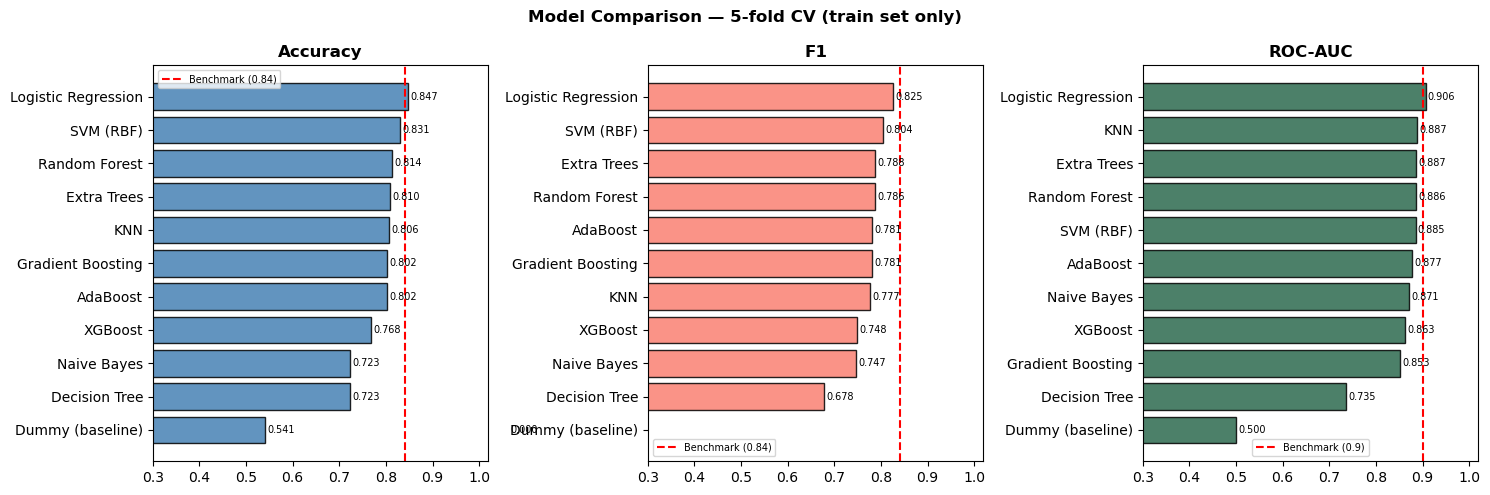

Top 3 models by ROC-AUC:
              Model  Accuracy       F1  ROC-AUC
Logistic Regression  0.847024 0.825353 0.906495
                KNN  0.805697 0.777230 0.887318
        Extra Trees  0.809609 0.788310 0.886604


In [64]:
# ── Visualise model comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, max(5, 0.45*len(results_df))))
metrics = ['Accuracy', 'F1', 'ROC-AUC']
colors = ['steelblue', 'salmon', '#2d6a4f']
benchmarks = [0.84, 0.84, 0.90]

for ax, metric, color, bench in zip(axes, metrics, colors, benchmarks):
    ordered = results_df.sort_values(metric)
    bars = ax.barh(ordered['Model'], ordered[metric],
                   color=color, edgecolor='black', alpha=0.85)
    ax.axvline(bench, color='red', linestyle='--', linewidth=1.5,
               label=f'Benchmark ({bench})')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(0.3, 1.02)
    ax.legend(fontsize=7)
    for bar, val in zip(bars, ordered[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7)

plt.suptitle('Model Comparison — 5-fold CV (train set only)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 3 models by ROC-AUC:')
print(results_df.head(3).to_string(index=False))

## ── CHUNK 4.5: Hyperparameter Tuning — Logistic Regression ───────────────────

Logistic Regression won the comparison. Now we try to squeeze more out of it by tuning its hyperparameters.

### The knobs we tune

| Parameter | What it controls | Values we try |
|---|---|---|
| `C` | Inverse regularization strength. **Low C = strong regularization** (simpler model, less overfit). High C = trust the data more. | `logspace(-3, 2)` (0.001 → 100) |
| `penalty` | Type of regularization: `l1` (Lasso — zeros out weak features), `l2` (Ridge — shrinks all), `elasticnet` (mix). | l1, l2, elasticnet |
| `solver` | The optimizer. `liblinear` supports l1/l2; `saga` supports elasticnet. | liblinear, saga |
| `l1_ratio` | For elasticnet only: 0 = pure l2, 1 = pure l1. | 0.25, 0.5, 0.75 |
| `class_weight` | `'balanced'` up-weights the minority class. | None, balanced |

### GridSearchCV vs RandomizedSearchCV
| | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| How | Tries **every** combination | Tries N random combinations |
| When | Small grid (our case — LogReg is fast) | Large grid / slow models |

Logistic Regression is cheap, so we use **GridSearchCV** here to test every combination exhaustively.

> Honest expectation: on a clean 303-row dataset, tuning usually moves ROC-AUC by only a small amount (±0.01). The default `C=1.0` is often already near-optimal. We tune to *confirm* that — and learn whether `l1` drops any features.

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Full pipeline: preprocessor + Logistic Regression
lr_pipe_tune = Pipeline([('pre', preprocessor),
                         ('clf', LogisticRegression(max_iter=2000, random_state=42))])

Cs = np.logspace(-3, 2, 10)   # 0.001 ... 100

# Param grid as a LIST of dicts (each dict = a valid solver/penalty combo)
param_grid = [
    # liblinear supports l1 and l2
    {'clf__solver': ['liblinear'],
     'clf__penalty': ['l1', 'l2'],
     'clf__C': Cs,
     'clf__class_weight': [None, 'balanced']},
    # saga supports elasticnet (needs more iterations)
    {'clf__solver': ['saga'],
     'clf__penalty': ['elasticnet'],
     'clf__l1_ratio': [0.25, 0.5, 0.75],
     'clf__C': Cs,
     'clf__class_weight': [None, 'balanced'],
     'clf__max_iter': [5000]},
]

grid = GridSearchCV(
    lr_pipe_tune, param_grid,
    cv=cv,                 # same 5-fold StratifiedKFold from Chunk 4
    scoring='roc_auc',     # optimise ranking quality
    n_jobs=-1,
    refit=True,
)

print('Searching... (this tries every combination — may take a minute)')
grid.fit(X_train, y_train)

print(f'\nBest ROC-AUC (CV): {grid.best_score_:.4f}')
print('Best parameters:')
for k, v in grid.best_params_.items():
    print(f'  {k:<22} = {v}')

Searching... (this tries every combination — may take a minute)

Best ROC-AUC (CV): 0.9130
Best parameters:
  clf__C                 = 0.1668100537200059
  clf__class_weight      = balanced
  clf__l1_ratio          = 0.25
  clf__max_iter          = 5000
  clf__penalty           = elasticnet
  clf__solver            = saga


In [66]:
# ── Did tuning actually help? Compare default vs tuned (same CV) ──────────────
from sklearn.model_selection import cross_val_score

# Default Logistic Regression (C=1.0, l2, lbfgs)
default_lr = Pipeline([('pre', preprocessor),
                       ('clf', LogisticRegression(max_iter=2000, random_state=42))])
default_auc = cross_val_score(default_lr, X_train, y_train, cv=cv,
                              scoring='roc_auc', n_jobs=-1).mean()

tuned_auc = grid.best_score_

print('Logistic Regression — Default vs Tuned (5-fold CV ROC-AUC):')
print(f'  Default (C=1.0, l2):  {default_auc:.4f}')
print(f'  Tuned (best params):  {tuned_auc:.4f}')
print(f'  Improvement:          {tuned_auc - default_auc:+.4f}')

if tuned_auc - default_auc < 0.005:
    print('\n-> Gain is within noise. The default was already near-optimal.')
    print('   This is the common outcome on small clean datasets - and a valid finding.')
else:
    print('\n-> Tuning gave a real improvement. Use the tuned model.')

# Save the best estimator so Chunk 5 can evaluate it on the test set
best_lr = grid.best_estimator_
print('\nbest_lr is ready — Chunk 5 will evaluate it on the locked test set.')

Logistic Regression — Default vs Tuned (5-fold CV ROC-AUC):
  Default (C=1.0, l2):  0.9065
  Tuned (best params):  0.9130
  Improvement:          +0.0066

-> Tuning gave a real improvement. Use the tuned model.

best_lr is ready — Chunk 5 will evaluate it on the locked test set.


## ── CHUNK 5: Final Evaluation on Test Set ────────────────────────────────────

### The rule: test set is LOCKED until the very end
We used cross-validation on the training set to pick AND tune the best model. Now we train on the full training set and evaluate **once** on the test set.

**We only look at the test set once.** Looking repeatedly and tweaking → leakage.

We evaluate the **tuned Logistic Regression** (`best_lr` from Chunk 4.5) against Gradient Boosting as a strong tree-based reference.

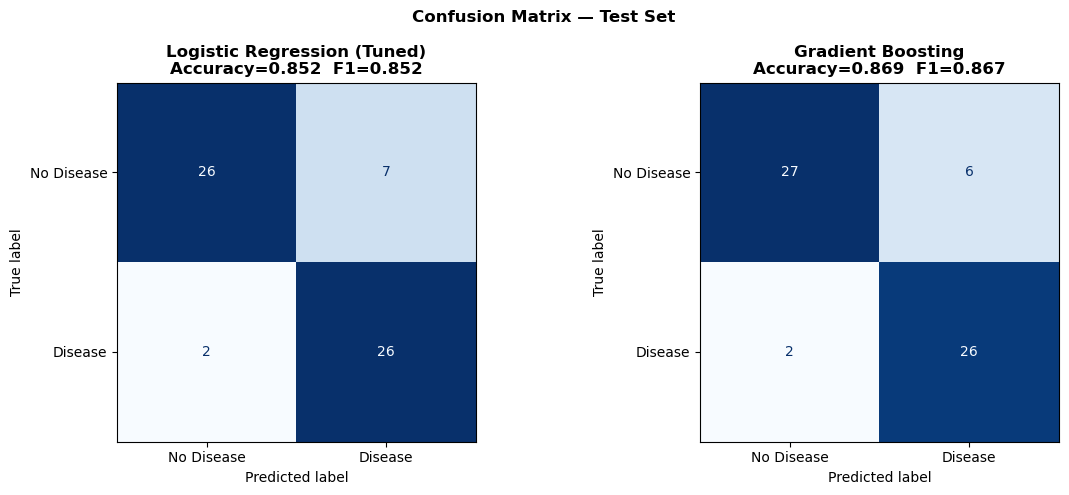

In [67]:
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, confusion_matrix, f1_score, accuracy_score
)
from sklearn.ensemble import GradientBoostingClassifier

# ── The tuned LR is already fitted by GridSearchCV (refit=True). ──────────────
# We train a Gradient Boosting model on the full training set as a comparison.
gb_final = Pipeline([('pre', preprocessor),
                     ('clf', GradientBoostingClassifier(random_state=42))])
gb_final.fit(X_train, y_train)

trained = {
    'Logistic Regression (Tuned)': best_lr,     # from Chunk 4.5
    'Gradient Boosting':           gb_final,
}

# ── Confusion matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pipe) in zip(axes, trained.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    f1  = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy={acc:.3f}  F1={f1:.3f}', fontweight='bold')

plt.suptitle('Confusion Matrix — Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

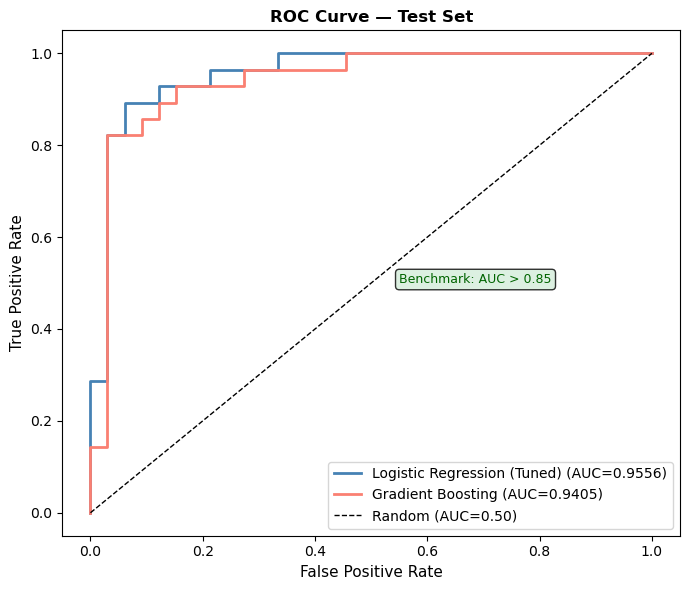

In [68]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
colors = ['steelblue', 'salmon']

for (name, pipe), color in zip(trained.items(), colors):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Test Set', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.annotate('Benchmark: AUC > 0.85', xy=(0.55, 0.50), fontsize=9,
            color='darkgreen',
            bbox=dict(boxstyle='round', facecolor='#d4edda', alpha=0.8))
plt.tight_layout()
plt.show()

In [69]:
# ── Full classification report ─────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

print('=' * 60)
print('FINAL EVALUATION — TEST SET (seen for the first time)')
print('=' * 60)

for name, pipe in trained.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    print(f'\n── {name} ──')
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))
    print(f'  ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

print('\nBenchmark: Logistic Regression ~0.80–0.88 accuracy, ROC-AUC ~0.85–0.90')
print('If you are above 0.95: investigate for leakage before celebrating!')

FINAL EVALUATION — TEST SET (seen for the first time)

── Logistic Regression (Tuned) ──
              precision    recall  f1-score   support

  No Disease       0.93      0.79      0.85        33
     Disease       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

  ROC-AUC: 0.9556

── Gradient Boosting ──
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

  ROC-AUC: 0.9405

Benchmark: Logistic Regression ~0.80–0.88 accuracy, ROC-AUC ~0.85–0.90
If you are above 0.95: investigate for leakage before celebrating!


## ── CHUNK 6: Feature Importance (Logistic Regression Coefficients) ──────────

### Why Logistic Regression is interpretable

Unlike Random Forest or XGBoost, Logistic Regression has coefficients you can read directly:
- **Positive coefficient** → feature pushes prediction toward Disease
- **Negative coefficient** → feature pushes prediction toward No Disease
- **Magnitude** → how strongly that feature influences the prediction

This links directly to what you saw in the EDA — do the important features from EDA have the largest coefficients?

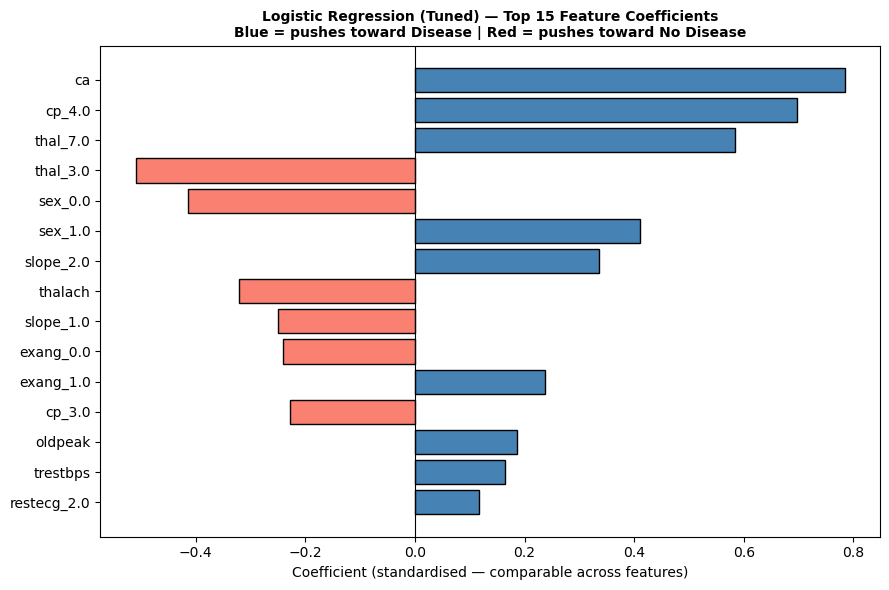

Note: if the tuned model used L1 penalty, some coefficients may be exactly 0
(L1 performs automatic feature selection by zeroing out weak features).

Cross-check with EDA:
  thalach (max heart rate): LOWER in disease patients -> negative coefficient
  oldpeak (ST depression):  HIGHER in disease patients -> positive coefficient


In [70]:
# ── Extract feature names after preprocessing ─────────────────────────────────
# 'pre' is a Pipeline: AgeGroupImputer -> ColumnTransformer.
# Drill into 'column_transform' to reach the OneHotEncoder.
lr_pipe = trained['Logistic Regression (Tuned)']

col_transform = lr_pipe.named_steps['pre'].named_steps['column_transform']
ohe_names = col_transform.named_transformers_['cat'].named_steps['ohe']\
                .get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(ohe_names)

coefficients = lr_pipe.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['Coefficient'][::-1]]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
        color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (standardised — comparable across features)', fontsize=10)
ax.set_title('Logistic Regression (Tuned) — Top 15 Feature Coefficients\n'
             'Blue = pushes toward Disease | Red = pushes toward No Disease',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print('Note: if the tuned model used L1 penalty, some coefficients may be exactly 0')
print('(L1 performs automatic feature selection by zeroing out weak features).')
print('\nCross-check with EDA:')
print('  thalach (max heart rate): LOWER in disease patients -> negative coefficient')
print('  oldpeak (ST depression):  HIGHER in disease patients -> positive coefficient')

## ── CHUNK 7: Rigor & Honesty Checks ─────────────────────────────────────────

The model works. These checks ask the harder question: **how much should we TRUST it, and what is it really doing?** This is the difference between a clean pipeline and a trustworthy one.

| Check | Question it answers |
|---|---|
| #5 Screening vs Diagnosis | Is the skill coming from baseline patient info, or from diagnostic-test results? |
| #1 Distribution not a point | How much does the score wobble? (test set is only ~61 rows) |
| #3 Bake-off error bars | Are the top models actually different, or statistically tied? |
| #4 Clinical threshold | Is 0.5 the right cutoff when a missed disease costs more than a false alarm? |
| #6 Learning curve | Would more data help, or are we data-saturated? |
| #7 Validation curve | What does the regularization (C) overfit→underfit arc look like? |

> **The small-data reality:** 20% of 303 ≈ 61 test patients. An accuracy on 61 people has a 95% CI of about ±10 points. So a single "final 0.84" is really "0.84, give or take a lot." These checks make that uncertainty visible instead of hiding it behind one confident number.

### #5 — Screening vs Diagnosis (the domain check that matters most)

Your strongest predictors — `cp`, `thalach`, `exang`, `oldpeak`, `slope`, `ca`, `thal` — are **results of the cardiac workup**, not baseline risk factors. They get measured *because* disease is already suspected.

That is not leakage (they are legitimate inputs), but it changes what the model IS:
- **With workup features** → a *diagnosis aid*: "given the test results, classify."
- **Without them (demographics only)** → a *screening tool*: "predict before any test."

We build a demographics-only model and measure how far performance falls. **That drop is the answer to: how much of the model's skill comes from the diagnostic tests themselves?**

Screening (demographics only) vs Diagnosis (full workup):
  Demographics-only ROC-AUC: 0.710 +/- 0.074
  Full features    ROC-AUC:  0.901 +/- 0.034
  Drop when workup tests removed: 0.191

Reading: that drop is the share of skill coming from diagnostic TEST results,
not from baseline patient characteristics. The full model is a DIAGNOSIS aid,
not a SCREENING tool. If the real task were screening, expect performance here.


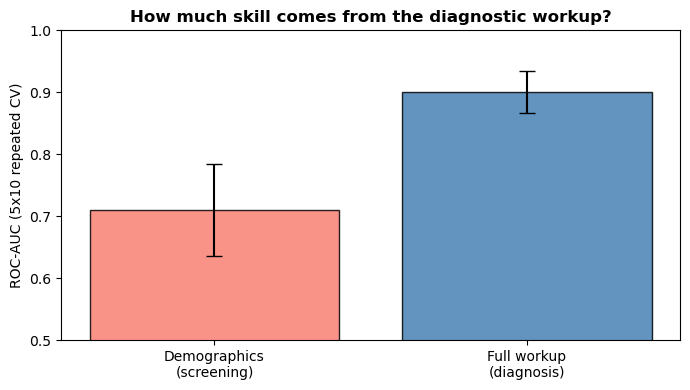

In [71]:
# === #5 Demographics-only vs Full-workup model ===============================
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Baseline / pre-workup features (known BEFORE any cardiac test)
demo_num = ['age', 'trestbps', 'chol']
demo_cat = ['sex', 'fbs', 'restecg']
# EXCLUDED (results of the workup): cp, thalach, exang, oldpeak, slope, ca, thal

demo_pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), demo_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), demo_cat),
])
demo_pipe = Pipeline([('pre', demo_pre),
                      ('clf', LogisticRegression(max_iter=2000, random_state=42))])

# 5x10 repeated CV = 50 estimates -> stable means
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
demo_auc = cross_val_score(demo_pipe, X_train, y_train, cv=rcv, scoring='roc_auc', n_jobs=-1)
full_auc = cross_val_score(best_lr,   X_train, y_train, cv=rcv, scoring='roc_auc', n_jobs=-1)

print('Screening (demographics only) vs Diagnosis (full workup):')
print(f'  Demographics-only ROC-AUC: {demo_auc.mean():.3f} +/- {demo_auc.std():.3f}')
print(f'  Full features    ROC-AUC:  {full_auc.mean():.3f} +/- {full_auc.std():.3f}')
print(f'  Drop when workup tests removed: {full_auc.mean() - demo_auc.mean():.3f}')
print()
print('Reading: that drop is the share of skill coming from diagnostic TEST results,')
print('not from baseline patient characteristics. The full model is a DIAGNOSIS aid,')
print('not a SCREENING tool. If the real task were screening, expect performance here.')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Demographics\n(screening)', 'Full workup\n(diagnosis)'],
       [demo_auc.mean(), full_auc.mean()],
       yerr=[demo_auc.std(), full_auc.std()], capsize=6,
       color=['salmon', 'steelblue'], edgecolor='black', alpha=0.85)
ax.set_ylabel('ROC-AUC (5x10 repeated CV)')
ax.set_ylim(0.5, 1.0)
ax.set_title('How much skill comes from the diagnostic workup?', fontweight='bold')
plt.tight_layout(); plt.show()

### #1 & #3 — Make the uncertainty visible

Two related honesty fixes for a small dataset:
- **#1** Report the score as a **distribution** (mean ± std over 50 folds), and show that the single hold-out test number is just *one draw* from that spread.
- **#3** Put **error bars** on the model bake-off — on 303 rows the top models are usually within 1 std of each other, i.e. statistically tied.

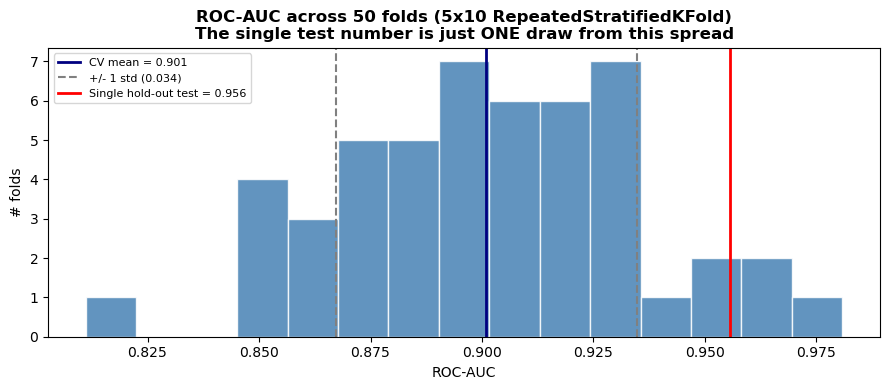

Honest headline: ROC-AUC = 0.901 +/- 0.034
The single hold-out (0.956) sits inside this spread - it is not special.


In [72]:
# === #1 Report a DISTRIBUTION, not a point ===================================
from sklearn.metrics import roc_auc_score

test_auc = roc_auc_score(y_test, best_lr.predict_proba(X_test)[:, 1])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(full_auc, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(full_auc.mean(), color='navy', linewidth=2, label=f'CV mean = {full_auc.mean():.3f}')
ax.axvline(full_auc.mean() - full_auc.std(), color='grey', linestyle='--',
           label=f'+/- 1 std ({full_auc.std():.3f})')
ax.axvline(full_auc.mean() + full_auc.std(), color='grey', linestyle='--')
ax.axvline(test_auc, color='red', linewidth=2, label=f'Single hold-out test = {test_auc:.3f}')
ax.set_xlabel('ROC-AUC'); ax.set_ylabel('# folds'); ax.legend(fontsize=8)
ax.set_title('ROC-AUC across 50 folds (5x10 RepeatedStratifiedKFold)\n'
             'The single test number is just ONE draw from this spread', fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Honest headline: ROC-AUC = {full_auc.mean():.3f} +/- {full_auc.std():.3f}')
print(f'The single hold-out ({test_auc:.3f}) sits inside this spread - it is not special.')

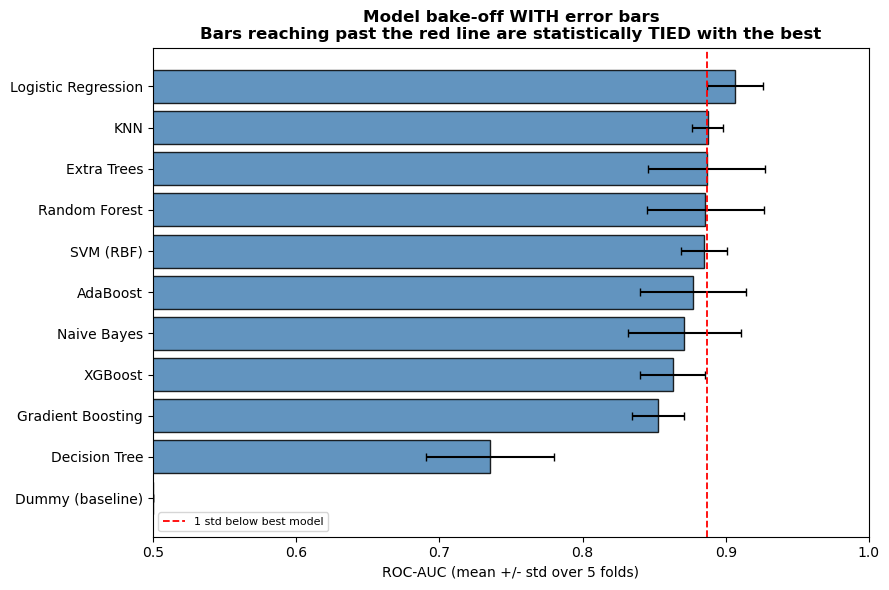

Takeaway: the top models overlap within 1 std -> statistically tied.
Pick Logistic Regression for interpretability + speed, not because it scored highest.


In [73]:
# === #3 Error bars on the model bake-off ====================================
# Reuse the models dict + cv from Chunk 4; recompute mean +/- std AUC per model.
bake = []
for name, model in models.items():
    p = Pipeline([('pre', preprocessor), ('clf', model)])
    s = cross_val_score(p, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    bake.append({'Model': name, 'mean': s.mean(), 'std': s.std()})
bake_df = pd.DataFrame(bake).sort_values('mean')

best_mean = bake_df['mean'].max()
best_std  = bake_df.loc[bake_df['mean'].idxmax(), 'std']

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(bake_df['Model'], bake_df['mean'], xerr=bake_df['std'],
        color='steelblue', edgecolor='black', alpha=0.85, capsize=3)
ax.axvline(best_mean - best_std, color='red', linestyle='--', linewidth=1.3,
           label='1 std below best model')
ax.set_xlabel('ROC-AUC (mean +/- std over 5 folds)')
ax.set_xlim(0.5, 1.0); ax.legend(fontsize=8)
ax.set_title('Model bake-off WITH error bars\n'
             'Bars reaching past the red line are statistically TIED with the best',
             fontweight='bold')
plt.tight_layout(); plt.show()

print('Takeaway: the top models overlap within 1 std -> statistically tied.')
print('Pick Logistic Regression for interpretability + speed, not because it scored highest.')

### #4 — Choose the decision threshold for the clinical cost

ROC-AUC is threshold-free, but the confusion matrix has to pick a cutoff — and 0.5 is an arbitrary default. In heart disease the errors are **not equal**: a false negative (missing real disease) is far costlier than a false positive.

So we (a) report **sensitivity** (Disease recall), not just accuracy, and (b) pick the threshold deliberately using **Youden's J** (maximises sensitivity + specificity − 1).

Threshold comparison on the test set:
  Default 0.50     sensitivity=0.929  specificity=0.788  precision=0.788
  Youden J 0.67    sensitivity=0.893  specificity=0.939  precision=0.926


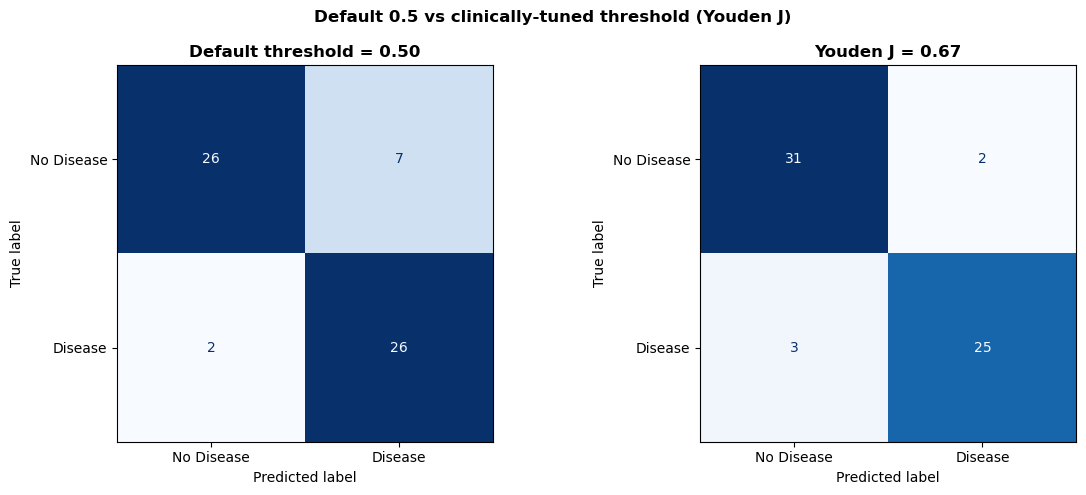


Clinical reading: a lower threshold catches MORE real disease (higher sensitivity)
at the cost of more false alarms. For screening, that trade is usually worth it.


In [74]:
# === #4 Pick a clinical operating threshold =================================
from sklearn.metrics import (roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                             recall_score, precision_score)

y_prob = best_lr.predict_proba(X_test)[:, 1]
fpr, tpr, thr = roc_curve(y_test, y_prob)
j_best = thr[(tpr - fpr).argmax()]      # Youden's J

print('Threshold comparison on the test set:')
for label, t in [('Default 0.50', 0.50), (f'Youden J {j_best:.2f}', j_best)]:
    yp   = (y_prob >= t).astype(int)
    sens = recall_score(y_test, yp, pos_label=1)    # sensitivity = Disease recall
    spec = recall_score(y_test, yp, pos_label=0)    # specificity
    prec = precision_score(y_test, yp, pos_label=1)
    print(f'  {label:<16} sensitivity={sens:.3f}  specificity={spec:.3f}  precision={prec:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, t) in zip(axes, [('Default threshold = 0.50', 0.50),
                                  (f'Youden J = {j_best:.2f}', j_best)]):
    yp = (y_prob >= t).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, yp),
                           display_labels=['No Disease', 'Disease']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(label, fontweight='bold')
plt.suptitle('Default 0.5 vs clinically-tuned threshold (Youden J)', fontweight='bold')
plt.tight_layout(); plt.show()

print()
print('Clinical reading: a lower threshold catches MORE real disease (higher sensitivity)')
print('at the cost of more false alarms. For screening, that trade is usually worth it.')

### #6 & #7 — Bias / variance made visible (your Chapter 4 material on your own data)

- **#6 Learning curve:** train vs validation score as the training set grows. Converged gap → data-saturated (more data will not help). Open gap → more data beats more tuning.
- **#7 Validation curve over C:** the overfit→underfit arc. Low C = underfit (too simple); high C = overfit (train ≫ val). The val peak is the sweet spot.

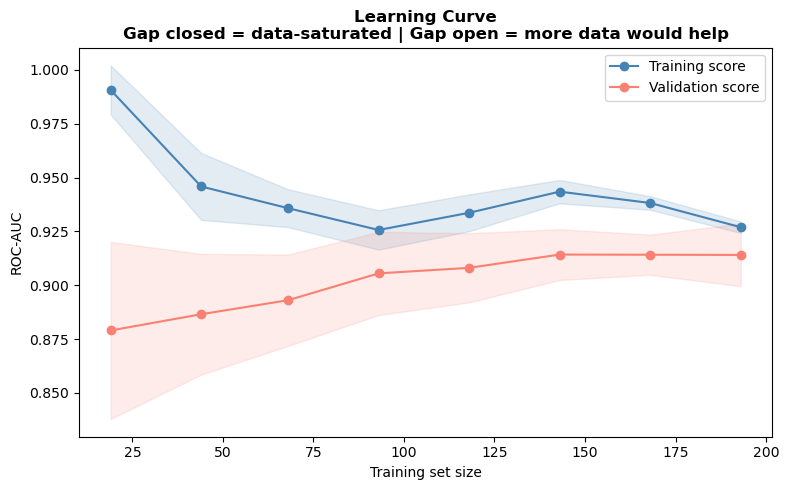

Reading: if the curves have converged, more data will NOT help - improve features
or accept the ceiling. If still separating, more data beats more tuning.


In [75]:
# === #6 Learning curve: would more DATA help? ==============================
from sklearn.model_selection import learning_curve

sizes, tr, va = learning_curve(
    best_lr, X_train, y_train, cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, tr.mean(1), 'o-', color='steelblue', label='Training score')
ax.fill_between(sizes, tr.mean(1)-tr.std(1), tr.mean(1)+tr.std(1), alpha=0.15, color='steelblue')
ax.plot(sizes, va.mean(1), 'o-', color='salmon', label='Validation score')
ax.fill_between(sizes, va.mean(1)-va.std(1), va.mean(1)+va.std(1), alpha=0.15, color='salmon')
ax.set_xlabel('Training set size'); ax.set_ylabel('ROC-AUC'); ax.legend()
ax.set_title('Learning Curve\nGap closed = data-saturated | Gap open = more data would help',
             fontweight='bold')
plt.tight_layout(); plt.show()

print('Reading: if the curves have converged, more data will NOT help - improve features')
print('or accept the ceiling. If still separating, more data beats more tuning.')

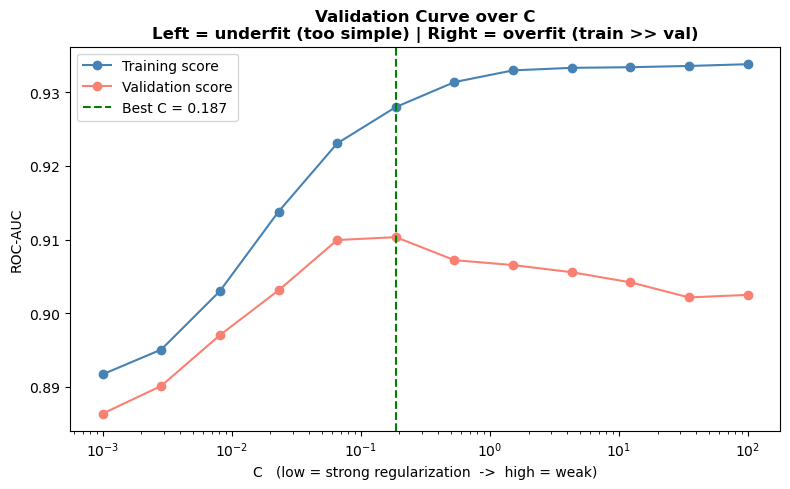

The validation score peaks near C = 0.187, then flattens/declines.
That is the overfit/underfit arc from your Chapter 4 notes, on your own data.


In [76]:
# === #7 Validation curve over C: SEE the regularization arc =================
from sklearn.model_selection import validation_curve

C_range = np.logspace(-3, 2, 12)
vc_pipe = Pipeline([('pre', preprocessor),
                    ('clf', LogisticRegression(penalty='l2', solver='liblinear',
                                               max_iter=2000, random_state=42))])
tr, va = validation_curve(
    vc_pipe, X_train, y_train, param_name='clf__C', param_range=C_range,
    cv=cv, scoring='roc_auc', n_jobs=-1)

best_c = C_range[va.mean(1).argmax()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(C_range, tr.mean(1), 'o-', color='steelblue', label='Training score')
ax.semilogx(C_range, va.mean(1), 'o-', color='salmon', label='Validation score')
ax.axvline(best_c, color='green', linestyle='--', label=f'Best C = {best_c:.3g}')
ax.set_xlabel('C   (low = strong regularization  ->  high = weak)')
ax.set_ylabel('ROC-AUC'); ax.legend()
ax.set_title('Validation Curve over C\nLeft = underfit (too simple) | Right = overfit (train >> val)',
             fontweight='bold')
plt.tight_layout(); plt.show()

print(f'The validation score peaks near C = {best_c:.3g}, then flattens/declines.')
print('That is the overfit/underfit arc from your Chapter 4 notes, on your own data.')

### Chunk 7 takeaways — what these checks changed

1. **The model is a diagnosis aid, not a screener.** Most of its skill comes from the cardiac-workup features; demographics alone score far lower.
2. **The real result is a range, not a point** — report `mean ± std`, treat the single test number as one draw.
3. **The top models are statistically tied** — LR wins on interpretability + speed, not because it scored highest.
4. **0.5 is not the right threshold clinically** — we chose an operating point that buys higher sensitivity (fewer missed patients).
5. **Selection tax is real** — `grid.best_score_` is optimistically biased; the honest, leakage-free estimate is **nested CV → that is project P4.**
6. **Bias/variance is visible now** — learning + validation curves show whether to chase more data, more features, or to stop.

## ── CHUNK 8: Summary + One-Paragraph Notes ───────────────────────────────────

### What did P1 add over the India Cancer project?

| Concept | India Cancer | P1 Heart Disease |
|---|---|---|
| Missing values | None | `ca` + `thal` — used SimpleImputer |
| Pipeline branches | 2 (num + cat) | 2, but each branch now has Impute → Transform |
| Dataset size | 100,000 rows | 303 rows — CV is critical |
| New model | — | SVM (small dataset, SVM feasible) |
| Interpretability | — | LR coefficients vs EDA features |
| Baseline check | Not explicit | DummyClassifier first |

### The core pipeline pattern (memorise this)
```python
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler',  StandardScaler())])

cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('ohe',     OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_pipeline, num_cols),
                                   ('cat', cat_pipeline, cat_cols)])

full_pipeline = Pipeline([('pre', preprocessor), ('clf', LogisticRegression())])
```
This pattern works for **any tabular dataset with mixed types and missing values**.

In [77]:
# ── Your one-paragraph notes entry for this project ───────────────────────────
# Write your own notes here after running through the notebook.
# Prompts:
#   1. What is the most important new thing you learned?
#   2. Where did imputation go inside the pipeline and why?
#   3. What did the LR coefficients tell you that the EDA had already shown?
#   4. Did you beat the benchmark? What was your final accuracy / AUC?

notes = """
P1 Notes (fill this in after running):
- New concept: SimpleImputer inside the Pipeline — learned that...
- My final accuracy: ___  ROC-AUC: ___  (benchmark: 0.84 / 0.90)
- LR coefficients confirmed the EDA: ...
- One thing I want to understand better: ...
"""
print(notes)


P1 Notes (fill this in after running):
- New concept: SimpleImputer inside the Pipeline — learned that...
- My final accuracy: ___  ROC-AUC: ___  (benchmark: 0.84 / 0.90)
- LR coefficients confirmed the EDA: ...
- One thing I want to understand better: ...



---
# 🧠 QUICK-RECALL — The Full Workflow of This Notebook

> Future me: read this to remember the whole pipeline in 2 minutes. Each step says **what** and **why**.

## CHUNK 1 — Load + EDA (understand before modelling)
1. **Load data**, check shape, dtypes, first rows.
2. **Binary target**: `(y > 0)` → 0 = no disease, 1 = disease.
3. **Missing values**: found `ca` (4) and `thal` (2). *Don't drop rows — impute.*
4. **Skewness + Kurtosis**: spot skewed columns (`chol`, `oldpeak`).
5. **Histograms**: see the shape of each feature.
6. **Outliers (IQR boxplots)**: detect, but KEEP if clinically real.
7. **Boxplots + t-test** (numeric vs target): which features separate the classes.
8. **Scatter plots** (with jitter): visualise feature ↔ target relationship.
9. **Pearson heatmap**: linear correlation + multicollinearity check.
10. **Spearman + effect size**: monotonic correlation (robust to non-linearity).
11. **Chi-square + ANOVA + η²** (categoricals): significance AND effect strength.
12. **VIF**: confirm no severe multicollinearity (all < 5).
13. **EDA summary**: write down which features are strong/weak + the impute plan.

## CHUNK 2 — Missing values
14. **Understand** the missing columns (value counts).
15. **AgeGroupImputer** (custom, leakage-safe): fill `ca` by age-band median, `thal` by age-band mode — the Titanic group-by-Title technique.
16. **Verify** the fills, confirm no NaN remain.

## CHUNK 3 — Pipeline
17. **Split FIRST** (`train_test_split`, stratified) — before any learned step.
18. **preprocessor** = `Pipeline([AgeGroupImputer → ColumnTransformer(num: impute+scale | cat: impute+OHE)])`.
19. Everything in ONE pipeline → re-fits per CV fold → **no leakage**.

## CHUNK 4 — Model comparison
20. **DummyClassifier baseline** first — must beat it.
21. Compare ~12 models (linear, KNN, NB, SVM, trees, boosting incl. **XGBoost/LightGBM**).
22. **5-fold StratifiedKFold**, rank by **ROC-AUC**.
23. Lesson: on small clean data, **Logistic Regression often beats boosting**.

## CHUNK 4.5 — Hyperparameter tuning
24. **GridSearchCV** on Logistic Regression: `C`, `penalty` (l1/l2/elasticnet), `solver`, `class_weight`.
25. **Compare default vs tuned** — keep the gain only if it clears the noise (~0.005).

## CHUNK 5 — Final evaluation (test set LOCKED until here)
26. Train tuned model on full train set, evaluate **ONCE** on test.
27. **Confusion matrix**, **ROC curve**, **classification report**.

## CHUNK 6 — Interpretability
28. **Logistic Regression coefficients**: + pushes to Disease, − to No Disease.
29. **Cross-check** the top coefficients against the EDA findings.
30. If L1 won: some coefficients are exactly 0 → automatic feature selection.

## CHUNK 7 — Rigor & honesty checks
31. **Demographics-only model** (#5): screening vs diagnosis — most skill comes from workup tests.
32. **RepeatedStratifiedKFold (5x10)** (#1): report mean +/- std, not one point.
33. **Bake-off error bars** (#3): top models are statistically tied -> pick LR for interpretability.
34. **Clinical threshold** (#4): Youden's J -> higher sensitivity (fewer missed patients) than 0.5.
35. **Learning curve** (#6): converged gap = data-saturated; open gap = more data helps.
36. **Validation curve over C** (#7): the overfit->underfit arc on your own data.
37. **Selection tax**: grid.best_score_ is optimistically biased; honest fix = nested CV = **P4**.

## CHUNK 8 — Notes
38. Write your own one-paragraph takeaway.

---
## 🔑 The 5 rules that never change
1. **Split before you learn anything** (impute/scale/encode) → avoids leakage.
2. **Beat the dumb baseline** or nothing else matters.
3. **Right metric**: ROC-AUC / F1, not just accuracy (especially if imbalanced).
4. **Significance ≠ strength**: always pair a p-value with an effect size.
5. **Distrust scores that are too good** — on small/leaky data, near-perfect = bug, not genius.

---
## 🧩 The reusable pipeline skeleton (copy this for any tabular project)
```python
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                     ('ohe',     OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', num_pipe, num_cols),
                                  ('cat', cat_pipe, cat_cols)])
full = Pipeline([('pre', preprocessor), ('clf', LogisticRegression())])
# split -> cross_validate -> GridSearchCV -> evaluate ONCE on test
```